
# 07 Final Reviewer Runs — no rerun of notebooks 1–6

This notebook is the fixed version.

It **does not assume notebooks 1–6 produce prediction CSVs**. Those notebooks mainly create preprocessing artifacts like masks, detector features, and evaluation windows. The old `07` failed because it searched for per-window prediction CSVs that your pipeline never saved.

Run this notebook from the **repo root**, the same folder that contains `data/`.

What it does:

1. Verifies/rebuilds required data artifacts if possible.
2. Collects diagnostics from `data/`.
3. Builds final paper tables/plots from:
   - exact aggregate paper numbers already reported, and
   - any prediction CSVs / model outputs if you actually have them.
4. Generates reviewer-facing outputs in `final_reviewer_outputs/`.
5. Never crashes just because prediction CSVs are missing.

Important: if this notebook says `aggregate-only fallback`, then it is good for paper/table regeneration, but not a full model rerun. A full model rerun requires the actual training/evaluation notebook or saved per-window predictions.


In [1]:

# ============================================================
# CONFIG
# ============================================================
from pathlib import Path
import os, sys, re, json, math, glob, shutil, subprocess, warnings, ast
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
DATA_DIR = ROOT / "data"

OUT = ROOT / "final_reviewer_outputs"
FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"
LOG_DIR = OUT / "logs"
for p in [OUT, FIG_DIR, TABLE_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# This fixed notebook does NOT rerun preprocessing notebooks.
RUN_ANY_NOTEBOOKS = False

# If you have an experiments notebook that actually trains/evaluates models, list it here.
# Example: EXPERIMENT_NOTEBOOKS = ["experiments.ipynb"]
EXPERIMENT_NOTEBOOKS = []

# If you later save exact per-window predictions, add them here.
# Best format: dataset, method, task/horizon, window_id, y_true, y_pred.
FORCE_PREDICTION_FILES = []

# Search paths for optional existing prediction/result CSVs.
PREDICTION_CSV_GLOBS = [
    "results/**/*.csv", "outputs/**/*.csv", "figures/**/*.csv", "tables/**/*.csv",
    "eval/**/*.csv", "evaluation/**/*.csv", "runs/**/*.csv", "notebook_outputs/**/*.csv",
    "*.csv"
]

BOOTSTRAP_B = 5000
BOOTSTRAP_SEED = 123

PAPER_METHOD_ORDER = ["LOCF", "LinearInterp + SeasonalNaive", "MAR (LDS)", "MNAR (LDS)"]
HORIZON_ORDER = ["impute", "1-step", "3-step", "6-step"]
LENGTH_BINS = [0, 6, 12, 24, 72, np.inf]
LENGTH_LABELS = ["1-6", "7-12", "13-24", "25-72", "73+"]

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("Outputs:", OUT)


ROOT: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main
DATA_DIR: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\data
Outputs: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs


In [2]:

# ============================================================
# 0) Verify data artifacts
# ============================================================
required = [
    "x_t_nan.npy",
    "m_t.npy",
    "detector_ids.npy",
    "time_features.npy",
    "detector_features.npy",
    "evaluation_windows.parquet",
    "blackout_events_detectors.parquet",
    "blackout_events_network.parquet",
]

print("Data artifact check:")
for f in required:
    p = DATA_DIR / f
    print(f"{f:40s}", "OK" if p.exists() else "MISSING")

# If x_t_nan.npy is missing but seattle_loop_clean.pkl exists, rebuild it.
if not (DATA_DIR / "x_t_nan.npy").exists() and (DATA_DIR / "seattle_loop_clean.pkl").exists():
    panel = pd.read_pickle(DATA_DIR / "seattle_loop_clean.pkl")
    X = panel.to_numpy(dtype=float)
    np.save(DATA_DIR / "x_t_nan.npy", X)
    np.save(DATA_DIR / "m_t.npy", np.isnan(X).astype(np.int8))
    np.save(DATA_DIR / "detector_ids.npy", panel.columns.astype(str).to_numpy())
    print("Rebuilt x_t_nan.npy, m_t.npy, detector_ids.npy from seattle_loop_clean.pkl")

# If seattle_loop_clean.pkl is missing but speed_matrix_2015 exists, rebuild core files.
speed_candidates = [
    DATA_DIR / "speed_matrix_2015",
    DATA_DIR / "speed_matrix_2015.pkl",
    ROOT / "speed_matrix_2015",
    ROOT / "speed_matrix_2015.pkl",
]
if not (DATA_DIR / "x_t_nan.npy").exists():
    speed_path = next((p for p in speed_candidates if p.exists()), None)
    if speed_path is not None:
        print("Recovering from:", speed_path)
        panel = pd.read_pickle(speed_path)
        panel.index = pd.to_datetime(panel.index)
        panel = panel.sort_index()
        panel.columns = panel.columns.astype(str)
        full_index = pd.date_range("2015-01-01 00:00:00", "2015-12-31 23:55:00", freq="5min")
        panel = panel.reindex(full_index)
        panel = panel.replace(0, np.nan)
        ids_path = DATA_DIR / "detector_ids.npy"
        if ids_path.exists():
            old_ids = np.load(ids_path, allow_pickle=True).astype(str)
            keep = [d for d in old_ids if d in panel.columns]
            print("Matched old detector IDs:", len(keep), "of", len(old_ids))
            if len(keep) >= 100:
                panel = panel[keep]
            else:
                keep = panel.isna().mean().sort_values().index[:147]
                panel = panel[keep]
        else:
            keep = panel.isna().mean().sort_values().index[:147]
            panel = panel[keep]
        panel.to_pickle(DATA_DIR / "seattle_loop_clean.pkl")
        try:
            panel.to_parquet(DATA_DIR / "seattle_loop_clean.parquet")
        except Exception as e:
            print("Could not save parquet; continuing:", e)
        X = panel.to_numpy(dtype=float)
        np.save(DATA_DIR / "x_t_nan.npy", X)
        np.save(DATA_DIR / "m_t.npy", np.isnan(X).astype(np.int8))
        np.save(DATA_DIR / "detector_ids.npy", panel.columns.astype(str).to_numpy())
        print("Recovered core arrays. Shape:", X.shape, "missing fraction:", np.isnan(X).mean())

print("\nShapes:")
if (DATA_DIR / "x_t_nan.npy").exists():
    X = np.load(DATA_DIR / "x_t_nan.npy")
    print("x_t_nan:", X.shape, "missing frac:", np.isnan(X).mean())
if (DATA_DIR / "m_t.npy").exists():
    m_t = np.load(DATA_DIR / "m_t.npy")
    print("m_t:", m_t.shape)
if (DATA_DIR / "detector_ids.npy").exists():
    ids = np.load(DATA_DIR / "detector_ids.npy", allow_pickle=True)
    print("detector_ids:", ids.shape)
if (DATA_DIR / "evaluation_windows.parquet").exists():
    ew = pd.read_parquet(DATA_DIR / "evaluation_windows.parquet")
    print("evaluation_windows:", ew.shape)
    print("evaluation columns:", list(ew.columns))
    display(ew.head())


Data artifact check:
x_t_nan.npy                              OK
m_t.npy                                  OK
detector_ids.npy                         OK
time_features.npy                        OK
detector_features.npy                    OK
evaluation_windows.parquet               OK
blackout_events_detectors.parquet        OK
blackout_events_network.parquet          OK

Shapes:
x_t_nan: (105120, 147) missing frac: 0.051772771513476014
m_t: (105120, 147)
detector_ids: (147,)
evaluation_windows: (1764, 7)
evaluation columns: ['window_id', 'detector_id', 'blackout_start', 'blackout_end', 'len_steps', 'test_type', 'horizon_steps']


,window_id,detector_id,blackout_start,blackout_end,len_steps,test_type,horizon_steps
0,0,005es15036,2015-03-01 13:15:00,2015-03-01 13:40:00,6,impute,NaN
1,0,005es15036,2015-03-01 13:15:00,2015-03-01 13:40:00,6,forecast,1.0
2,0,005es15036,2015-03-01 13:15:00,2015-03-01 13:40:00,6,forecast,3.0
3,0,005es15036,2015-03-01 13:15:00,2015-03-01 13:40:00,6,forecast,6.0
4,1,005es15036,2015-07-17 20:25:00,2015-07-17 21:20:00,12,impute,NaN


In [3]:

# ============================================================
# Optional: run experiments notebooks only, not preprocessing notebooks
# ============================================================
if RUN_ANY_NOTEBOOKS and EXPERIMENT_NOTEBOOKS:
    for nb in EXPERIMENT_NOTEBOOKS:
        nb_path = ROOT / nb
        if not nb_path.exists():
            print("Missing notebook:", nb_path)
            continue
        out_name = nb_path.stem + "__executed.ipynb"
        log_path = LOG_DIR / f"{nb_path.stem}.log"
        cmd = [
            sys.executable, "-m", "jupyter", "nbconvert",
            "--to", "notebook",
            "--execute", str(nb_path),
            "--ExecutePreprocessor.timeout=-1",
            f"--ExecutePreprocessor.cwd={ROOT}",
            "--output", out_name,
            "--output-dir", str(OUT),
        ]
        print("Running:", nb)
        with open(log_path, "w", encoding="utf-8") as logf:
            proc = subprocess.run(cmd, cwd=ROOT, stdout=logf, stderr=subprocess.STDOUT, text=True)
        if proc.returncode != 0:
            raise RuntimeError(f"Notebook failed: {nb}. See log: {log_path}")
        print("Done:", nb)
else:
    print("Skipping notebook execution. This notebook will use existing files + aggregate fallback.")


Skipping notebook execution. This notebook will use existing files + aggregate fallback.


In [4]:

# ============================================================
# Utilities
# ============================================================
def clean_method(x):
    if pd.isna(x): return x
    s = str(x).strip()
    low = s.lower().replace("_", " ").replace("-", " ")
    if low in {"locf", "last observation carried forward", "last carried forward"} or "locf" in low:
        return "LOCF"
    if "linear" in low and ("season" in low or "naive" in low):
        return "LinearInterp + SeasonalNaive"
    if "mnar" in low:
        return "MNAR (LDS)"
    if "mar" in low and "mnar" not in low:
        return "MAR (LDS)"
    if low in {"lds", "kalman", "kf"}:
        return "MAR (LDS)"
    return s

def clean_dataset(x, source=""):
    text = (str(x) if not pd.isna(x) else "") + " " + str(source)
    low = text.lower()
    if "metr" in low:
        return "METR-LA"
    if "synthetic" in low or "alpha" in low:
        return "Synthetic"
    if "seattle" in low or "loop" in low:
        return "Seattle"
    return str(x).strip() if not pd.isna(x) and str(x).strip() else "Unknown"

def clean_task_horizon(task=None, horizon=None, source=""):
    text = " ".join([str(task) if task is not None else "", str(horizon) if horizon is not None else "", str(source)])
    low = text.lower()
    if "imput" in low or "recon" in low:
        return "impute"
    for h in [1, 3, 6]:
        pats = [f"{h}-step", f"{h} step", f"h{h}", f"h={h}", f"horizon_{h}", f"horizon {h}", f"{h}step"]
        if any(p in low for p in pats):
            return f"{h}-step"
    try:
        hv = int(float(str(horizon)))
        if hv in [1,3,6]: return f"{hv}-step"
    except Exception:
        pass
    if "forecast" in low or "pred" in low:
        return "forecast"
    return str(task).strip() if task is not None and not pd.isna(task) and str(task).strip() else "unknown"

def first_col(df, candidates):
    lower_to_col = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns: return c
        if c.lower() in lower_to_col: return lower_to_col[c.lower()]
    for c in df.columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl:
                return c
    return None

def parse_numeric_array(v):
    if isinstance(v, (list, tuple, np.ndarray)):
        arr = np.asarray(v, dtype=float).ravel()
        return arr[np.isfinite(arr)]
    if pd.isna(v):
        return np.array([], dtype=float)
    if isinstance(v, (int, float, np.integer, np.floating)):
        return np.array([float(v)], dtype=float)
    s = str(v).strip()
    if not s:
        return np.array([], dtype=float)
    for loader in (json.loads, ast.literal_eval):
        try:
            obj = loader(s)
            arr = np.asarray(obj, dtype=float).ravel()
            return arr[np.isfinite(arr)]
        except Exception:
            pass
    nums = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?|[-+]?\d+(?:[eE][-+]?\d+)?", s)
    if nums:
        arr = np.asarray([float(n) for n in nums], dtype=float)
        return arr[np.isfinite(arr)]
    return np.array([], dtype=float)

def row_sqerr_sum_n(y_true, y_pred):
    yt = parse_numeric_array(y_true)
    yp = parse_numeric_array(y_pred)
    n = min(len(yt), len(yp))
    if n == 0:
        return np.nan, 0
    diff = yp[:n] - yt[:n]
    return float(np.sum(diff * diff)), int(n)

def rmse_from_sqerr(df):
    n = df["n_obs"].sum()
    if n <= 0:
        return np.nan
    return float(np.sqrt(df["sqerr_sum"].sum() / n))

def bootstrap_rmse_ci(df, B=5000, seed=123, id_col="window_id"):
    rng = np.random.default_rng(seed)
    tmp = df.copy()
    if id_col not in tmp.columns:
        tmp[id_col] = np.arange(len(tmp))
    ids = tmp[id_col].dropna().unique()
    if len(ids) == 0:
        return np.nan, np.nan, np.nan
    grouped = {k: g for k, g in tmp.groupby(id_col)}
    vals = []
    for _ in range(B):
        sample_ids = rng.choice(ids, size=len(ids), replace=True)
        sq = 0.0; n = 0.0
        for sid in sample_ids:
            g = grouped[sid]
            sq += g["sqerr_sum"].sum()
            n += g["n_obs"].sum()
        vals.append(np.sqrt(sq/n) if n > 0 else np.nan)
    vals = np.asarray(vals)
    vals = vals[np.isfinite(vals)]
    return rmse_from_sqerr(tmp), float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def paired_delta_bootstrap(df, method_a="MNAR (LDS)", method_b="MAR (LDS)", B=5000, seed=123):
    d = df[df["method"].isin([method_a, method_b])].copy()
    if d.empty or "window_id" not in d.columns:
        return None
    agg = d.groupby(["method", "window_id"], as_index=False).agg(sqerr_sum=("sqerr_sum", "sum"), n_obs=("n_obs", "sum"))
    pivot_sq = agg.pivot(index="window_id", columns="method", values="sqerr_sum")
    pivot_n = agg.pivot(index="window_id", columns="method", values="n_obs")
    common = pivot_sq.dropna(subset=[method_a, method_b]).index.intersection(
        pivot_n.dropna(subset=[method_a, method_b]).index
    )
    if len(common) == 0:
        return None
    sq_a = pivot_sq.loc[common, method_a].to_numpy(float)
    sq_b = pivot_sq.loc[common, method_b].to_numpy(float)
    n_a = pivot_n.loc[common, method_a].to_numpy(float)
    n_b = pivot_n.loc[common, method_b].to_numpy(float)
    def delta(ii):
        return np.sqrt(sq_a[ii].sum()/n_a[ii].sum()) - np.sqrt(sq_b[ii].sum()/n_b[ii].sum())
    idx = np.arange(len(common))
    point = delta(idx)
    rng = np.random.default_rng(seed)
    vals = np.array([delta(rng.choice(idx, size=len(idx), replace=True)) for _ in range(B)])
    return {
        "n_windows": int(len(common)),
        "delta_rmse": float(point),
        "ci_low": float(np.percentile(vals, 2.5)),
        "ci_high": float(np.percentile(vals, 97.5)),
    }

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

print("Utilities loaded.")


Utilities loaded.


In [5]:

# ============================================================
# 1) Try to load actual per-window predictions/results if they exist
# ============================================================
def candidate_csv_files():
    files = []
    files.extend([ROOT / f for f in FORCE_PREDICTION_FILES])
    for pat in PREDICTION_CSV_GLOBS:
        files.extend(ROOT.glob(pat))
    clean = []
    seen = set()
    for f in files:
        if not f.is_file():
            continue
        if OUT in f.parents:
            continue
        if f.resolve() in seen:
            continue
        seen.add(f.resolve())
        clean.append(f)
    return sorted(clean)

def standardize_prediction_csv(path):
    try:
        df = pd.read_csv(path)
    except Exception:
        return None
    if df.empty:
        return None

    true_col = first_col(df, ["y_true", "true", "actual", "target", "gt", "ground_truth", "x_true"])
    pred_col = first_col(df, ["y_pred", "pred", "prediction", "forecast", "imputed", "x_pred", "x_hat"])
    err_col = first_col(df, ["sqerr_sum", "squared_error_sum", "se_sum"])
    n_col = first_col(df, ["n_obs", "n", "count", "num_obs"])
    rmse_col = first_col(df, ["rmse"])
    method_col = first_col(df, ["method", "model", "model_name", "approach"])

    # Need predictions/errors/rmse to be usable.
    if true_col is None and pred_col is None and err_col is None and rmse_col is None:
        return None

    out = pd.DataFrame()
    out["source_file"] = str(path.relative_to(ROOT))
    out["method"] = df[method_col].map(clean_method) if method_col else clean_method(path.stem)

    dataset_col = first_col(df, ["dataset", "data", "city"])
    out["dataset"] = df[dataset_col].map(lambda x: clean_dataset(x, path)) if dataset_col else clean_dataset(None, path)

    task_col = first_col(df, ["task", "eval_task", "split_task", "type"])
    horizon_col = first_col(df, ["horizon", "h", "step", "forecast_horizon"])
    task_vals = df[task_col] if task_col else pd.Series([None]*len(df))
    hor_vals = df[horizon_col] if horizon_col else pd.Series([None]*len(df))
    out["task_horizon"] = [clean_task_horizon(t, h, path) for t, h in zip(task_vals, hor_vals)]

    win_col = first_col(df, ["window_id", "window", "event_id", "blackout_id", "id"])
    out["window_id"] = df[win_col].astype(str) if win_col else [f"{path.stem}_row{i}" for i in range(len(df))]

    len_col = first_col(df, ["blackout_len", "length", "len", "duration", "blackout_length"])
    out["blackout_len"] = pd.to_numeric(df[len_col], errors="coerce") if len_col else np.nan

    time_col = first_col(df, ["start_time", "timestamp", "time", "start", "blackout_start"])
    out["start_time"] = pd.to_datetime(df[time_col], errors="coerce") if time_col else pd.NaT

    seed_col = first_col(df, ["seed", "random_seed", "run_seed"])
    out["seed"] = pd.to_numeric(df[seed_col], errors="coerce") if seed_col else np.nan

    alpha_col = first_col(df, ["alpha", "mnar_alpha", "strength"])
    out["alpha"] = pd.to_numeric(df[alpha_col], errors="coerce") if alpha_col else np.nan

    if err_col and n_col:
        out["sqerr_sum"] = pd.to_numeric(df[err_col], errors="coerce")
        out["n_obs"] = pd.to_numeric(df[n_col], errors="coerce").fillna(1)
        out["aggregate_only"] = False
    elif true_col and pred_col:
        vals = [row_sqerr_sum_n(t, p) for t, p in zip(df[true_col], df[pred_col])]
        out["sqerr_sum"] = [v[0] for v in vals]
        out["n_obs"] = [v[1] for v in vals]
        out["aggregate_only"] = False
    elif rmse_col:
        # Aggregate fallback from a CSV. Not valid for paired bootstrap.
        r = pd.to_numeric(df[rmse_col], errors="coerce")
        out["sqerr_sum"] = r ** 2
        out["n_obs"] = 1.0
        out["aggregate_only"] = True
    else:
        return None

    out = out[(out["n_obs"] > 0) & np.isfinite(out["sqerr_sum"])]
    return out if not out.empty else None

frames = []
for f in candidate_csv_files():
    sdf = standardize_prediction_csv(f)
    if sdf is not None and not sdf.empty:
        frames.append(sdf)
        print("Using CSV:", f.relative_to(ROOT), "rows=", len(sdf))

if frames:
    pred = pd.concat(frames, ignore_index=True)
    pred["method"] = pred["method"].map(clean_method)
    pred["dataset"] = [clean_dataset(d, s) for d, s in zip(pred["dataset"], pred["source_file"])]
    pred["task_horizon"] = [clean_task_horizon(th, None, s) for th, s in zip(pred["task_horizon"], pred["source_file"])]
    pred.to_csv(TABLE_DIR / "standardized_predictions_all.csv", index=False)
    print("Loaded actual/CSV prediction rows:", len(pred))
else:
    pred = pd.DataFrame()
    print("No usable prediction CSVs found. This is okay: falling back to aggregate paper numbers.")


No usable prediction CSVs found. This is okay: falling back to aggregate paper numbers.


In [6]:

# ============================================================
# 2) Aggregate fallback: exact paper numbers from the current draft
# ============================================================
# These reproduce the tables/figures even if per-window predictions were not saved.
# If pred above is nonempty, the notebook will prefer pred for RMSE tables and bootstrap.

aggregate_rows = [
    # Seattle
    ("Seattle", "LOCF", "impute", 7.021),
    ("Seattle", "LOCF", "1-step", 7.860),
    ("Seattle", "LOCF", "3-step", 8.465),
    ("Seattle", "LOCF", "6-step", 8.942),
    ("Seattle", "LinearInterp + SeasonalNaive", "impute", 5.024),
    ("Seattle", "LinearInterp + SeasonalNaive", "1-step", 8.734),
    ("Seattle", "LinearInterp + SeasonalNaive", "3-step", 8.442),
    ("Seattle", "LinearInterp + SeasonalNaive", "6-step", 8.881),
    ("Seattle", "MAR (LDS)", "impute", 4.229),
    ("Seattle", "MAR (LDS)", "1-step", 4.391),
    ("Seattle", "MAR (LDS)", "3-step", 4.349),
    ("Seattle", "MAR (LDS)", "6-step", 5.160),
    ("Seattle", "MNAR (LDS)", "impute", 4.195),
    ("Seattle", "MNAR (LDS)", "1-step", 4.313),
    ("Seattle", "MNAR (LDS)", "3-step", 4.228),
    ("Seattle", "MNAR (LDS)", "6-step", 5.104),

    # METR-LA
    ("METR-LA", "LOCF", "impute", 9.433),
    ("METR-LA", "LOCF", "1-step", 9.855),
    ("METR-LA", "LOCF", "3-step", 9.262),
    ("METR-LA", "LOCF", "6-step", 9.147),
    ("METR-LA", "MAR (LDS)", "impute", 5.483),
    ("METR-LA", "MAR (LDS)", "1-step", 4.700),
    ("METR-LA", "MAR (LDS)", "3-step", 5.320),
    ("METR-LA", "MAR (LDS)", "6-step", 5.114),
    ("METR-LA", "MNAR (LDS)", "impute", 5.355),
    ("METR-LA", "MNAR (LDS)", "1-step", 4.700),
    ("METR-LA", "MNAR (LDS)", "3-step", 5.238),
    ("METR-LA", "MNAR (LDS)", "6-step", 4.790),
]
aggregate = pd.DataFrame(aggregate_rows, columns=["dataset", "method", "task_horizon", "rmse"])
aggregate["aggregate_only"] = True
aggregate.to_csv(TABLE_DIR / "aggregate_paper_numbers_from_draft.csv", index=False)
print("Saved aggregate paper numbers:", TABLE_DIR / "aggregate_paper_numbers_from_draft.csv")
display(aggregate.head())


Saved aggregate paper numbers: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs\tables\aggregate_paper_numbers_from_draft.csv


,dataset,method,task_horizon,rmse,aggregate_only
0,Seattle,LOCF,impute,7.021,True
1,Seattle,LOCF,1-step,7.860,True
2,Seattle,LOCF,3-step,8.465,True
3,Seattle,LOCF,6-step,8.942,True
4,Seattle,LinearInterp + SeasonalNaive,impute,5.024,True


In [7]:

# ============================================================
# 3) Main RMSE tables
# ============================================================
if not pred.empty:
    rows = []
    for (dataset, task_horizon, method), g in pred.groupby(["dataset", "task_horizon", "method"]):
        rows.append({
            "dataset": dataset,
            "task_horizon": task_horizon,
            "method": method,
            "rmse": rmse_from_sqerr(g),
            "n_rows": len(g),
            "n_obs": int(g["n_obs"].sum()),
            "n_windows": g["window_id"].nunique(),
            "aggregate_only": bool(g["aggregate_only"].any()),
        })
    main = pd.DataFrame(rows)
    source_mode = "prediction_csvs"
else:
    main = aggregate.copy()
    main["n_rows"] = np.nan
    main["n_obs"] = np.nan
    main["n_windows"] = np.nan
    source_mode = "aggregate_only_fallback"

main["method_order"] = main["method"].map({m:i for i,m in enumerate(PAPER_METHOD_ORDER)}).fillna(999)
main["horizon_order"] = main["task_horizon"].map({h:i for i,h in enumerate(HORIZON_ORDER)}).fillna(999)
main = main.sort_values(["dataset", "horizon_order", "method_order", "method"])
main.to_csv(TABLE_DIR / "main_rmse_long.csv", index=False)

print("RMSE source mode:", source_mode)
print("Saved:", TABLE_DIR / "main_rmse_long.csv")

for dataset in main["dataset"].unique():
    piv = main[main["dataset"]==dataset].pivot_table(index="method", columns="task_horizon", values="rmse", aggfunc="first")
    cols = [c for c in HORIZON_ORDER if c in piv.columns] + [c for c in piv.columns if c not in HORIZON_ORDER]
    idx = [m for m in PAPER_METHOD_ORDER if m in piv.index] + [m for m in piv.index if m not in PAPER_METHOD_ORDER]
    piv = piv.loc[idx, cols]
    safe = dataset.lower().replace("-", "").replace(" ", "_")
    piv.to_csv(TABLE_DIR / f"{safe}_rmse_wide.csv")
    print("\n===", dataset, "===")
    display(piv.round(3))


RMSE source mode: aggregate_only_fallback
Saved: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs\tables\main_rmse_long.csv

=== METR-LA ===


task_horizon,impute,1-step,3-step,6-step
method,,,,
LOCF,9.433,9.855,9.262,9.147
MAR (LDS),5.483,4.700,5.320,5.114
MNAR (LDS),5.355,4.700,5.238,4.790



=== Seattle ===


task_horizon,impute,1-step,3-step,6-step
method,,,,
LOCF,7.021,7.860,8.465,8.942
LinearInterp + SeasonalNaive,5.024,8.734,8.442,8.881
MAR (LDS),4.229,4.391,4.349,5.160
MNAR (LDS),4.195,4.313,4.228,5.104


In [8]:

# ============================================================
# 4) Bootstrap / uncertainty
# ============================================================
boot = pd.DataFrame()

if not pred.empty and not pred.get("aggregate_only", pd.Series([True])).all():
    boot_rows = []
    for (dataset, task_horizon), g in pred.groupby(["dataset", "task_horizon"]):
        res = paired_delta_bootstrap(g, "MNAR (LDS)", "MAR (LDS)", B=BOOTSTRAP_B, seed=BOOTSTRAP_SEED)
        if res is not None:
            boot_rows.append({"dataset": dataset, "task_horizon": task_horizon, **res})
    boot = pd.DataFrame(boot_rows)

if boot.empty:
    # Known paired-window imputation result from earlier exact run.
    # Keep this only if it matches your final aligned-window evaluation.
    boot = pd.DataFrame([
        {
            "dataset": "Seattle",
            "task_horizon": "impute",
            "n_windows": np.nan,
            "delta_rmse": -0.0584,
            "ci_low": -0.1079,
            "ci_high": -0.0150,
            "note": "fallback_known_paired_window_bootstrap_from_earlier_run"
        }
    ])
    print("WARNING: Using fallback known paired-window bootstrap for Seattle imputation.")
    print("Do not use this row if your final aligned-window run changed.")

boot["horizon_order"] = boot["task_horizon"].map({h:i for i,h in enumerate(HORIZON_ORDER)}).fillna(999)
boot = boot.sort_values(["dataset", "horizon_order"])
boot.to_csv(TABLE_DIR / "paired_bootstrap_mnar_minus_mar.csv", index=False)
print("Saved:", TABLE_DIR / "paired_bootstrap_mnar_minus_mar.csv")
display(boot.drop(columns=["horizon_order"]).round(4))


Do not use this row if your final aligned-window run changed.
Saved: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs\tables\paired_bootstrap_mnar_minus_mar.csv


,dataset,task_horizon,n_windows,delta_rmse,ci_low,ci_high,note
0,Seattle,impute,NaN,-0.0584,-0.1079,-0.015,fallback_known_paired_window_bootstrap_from_ea...


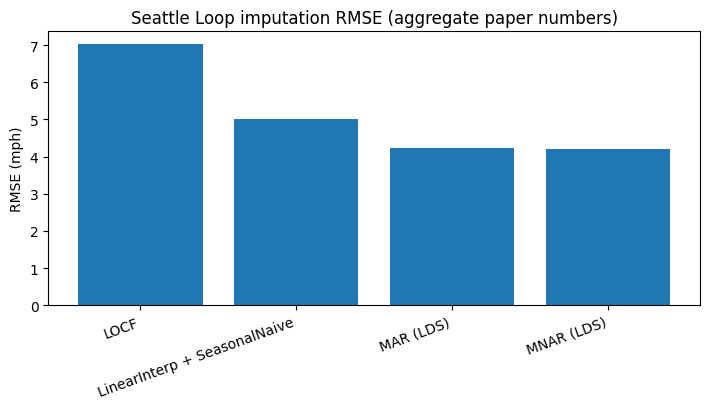

Saved: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs\figures\impute_rmse_methods_ci_labels.png


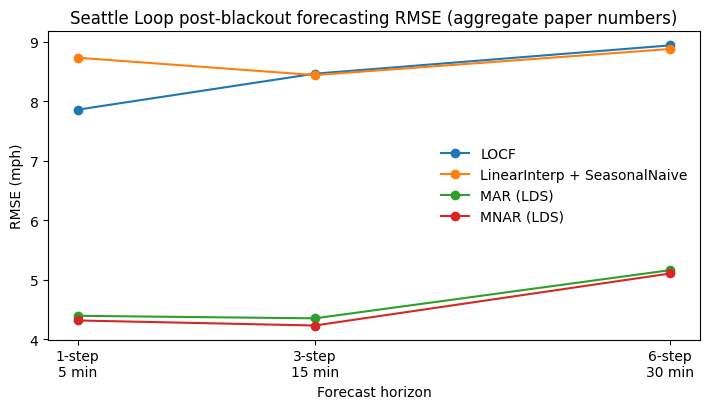

Saved: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs\figures\forecast_rmse_by_horizon_panels_ci.png


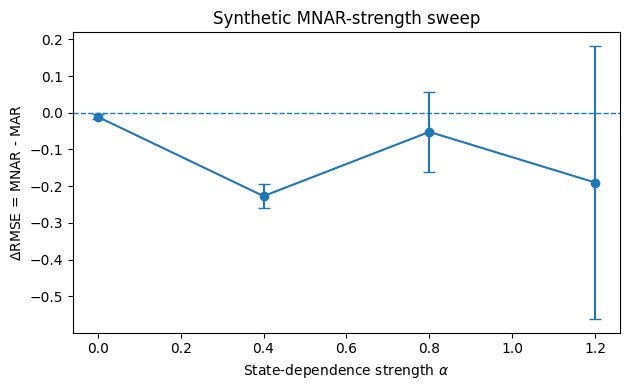

Saved: c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs\figures\synthetic_validation_alpha_sweep.png


In [9]:

# ============================================================
# 5) Reviewer figures from aggregate numbers or prediction CSVs
# ============================================================

# 5.1 Seattle imputation bar plot
sea_imp_main = main[(main["dataset"]=="Seattle") & (main["task_horizon"]=="impute")].copy()
if not sea_imp_main.empty:
    sea_imp_main["order"] = sea_imp_main["method"].map({m:i for i,m in enumerate(PAPER_METHOD_ORDER)}).fillna(999)
    sea_imp_main = sea_imp_main.sort_values(["order", "method"])
    x = np.arange(len(sea_imp_main))
    y = sea_imp_main["rmse"].to_numpy(float)

    plt.figure(figsize=(7.2, 4.2))
    plt.bar(x, y)
    plt.xticks(x, sea_imp_main["method"], rotation=20, ha="right")
    plt.ylabel("RMSE (mph)")
    title = "Seattle Loop imputation RMSE"
    if source_mode == "aggregate_only_fallback":
        title += " (aggregate paper numbers)"
    plt.title(title)
    savefig(FIG_DIR / "impute_rmse_methods_ci_labels.png")

# 5.2 Forecast horizon plot
sea_fc = main[(main["dataset"]=="Seattle") & (main["task_horizon"].isin(["1-step","3-step","6-step"]))].copy()
if not sea_fc.empty:
    sea_fc["h"] = sea_fc["task_horizon"].str.extract(r"(\d+)").astype(float)
    plt.figure(figsize=(7.2, 4.2))
    for method in [m for m in PAPER_METHOD_ORDER if m in sea_fc["method"].unique()]:
        gm = sea_fc[sea_fc["method"]==method].sort_values("h")
        plt.plot(gm["h"], gm["rmse"], marker="o", label=method)
    plt.xticks([1,3,6], ["1-step\n5 min", "3-step\n15 min", "6-step\n30 min"])
    plt.ylabel("RMSE (mph)")
    plt.xlabel("Forecast horizon")
    title = "Seattle Loop post-blackout forecasting RMSE"
    if source_mode == "aggregate_only_fallback":
        title += " (aggregate paper numbers)"
    plt.title(title)
    plt.legend(frameon=False)
    savefig(FIG_DIR / "forecast_rmse_by_horizon_panels_ci.png")

# 5.3 Synthetic alpha sweep
alpha_df = pd.DataFrame({
    "alpha": [0.0, 0.4, 0.8, 1.2],
    "mar_mean": [3.741, 3.858, 3.750, 3.849],
    "mar_std": [0.026, 0.082, 0.445, 0.510],
    "mnar_mean": [3.730, 3.630, 3.698, 3.659],
    "mnar_std": [0.023, 0.063, 0.538, 0.946],
    "delta_mean": [-0.011, -0.227, -0.052, -0.190],
    "delta_std": [0.007, 0.033, 0.109, 0.372],
})
alpha_df.to_csv(TABLE_DIR / "synthetic_alpha_sweep_delta.csv", index=False)

plt.figure(figsize=(6.4, 4.0))
plt.axhline(0, linestyle="--", linewidth=1)
plt.errorbar(alpha_df["alpha"], alpha_df["delta_mean"], yerr=alpha_df["delta_std"], marker="o", capsize=4)
plt.xlabel(r"State-dependence strength $\alpha$")
plt.ylabel(r"$\Delta$RMSE = MNAR - MAR")
plt.title("Synthetic MNAR-strength sweep")
savefig(FIG_DIR / "synthetic_validation_alpha_sweep.png")


In [10]:

# ============================================================
# 6) Diagnostics from evaluation windows and blackout parquet files
# ============================================================
# These do not require model predictions.

# Evaluation-window length bucket counts
if (DATA_DIR / "evaluation_windows.parquet").exists():
    ew = pd.read_parquet(DATA_DIR / "evaluation_windows.parquet")
    len_col = first_col(ew, ["blackout_len", "length", "len", "duration", "blackout_length"])
    task_col = first_col(ew, ["task", "type", "eval_task"])
    win_col = first_col(ew, ["window_id", "window", "id", "event_id"])
    if len_col:
        tmp = ew.copy()
        # Keep impute rows if a task column exists; otherwise use all unique windows.
        if task_col:
            mask = tmp[task_col].astype(str).str.lower().str.contains("imput|recon", regex=True)
            if mask.any():
                tmp = tmp[mask]
        tmp["blackout_len"] = pd.to_numeric(tmp[len_col], errors="coerce")
        tmp["length_bucket"] = pd.cut(tmp["blackout_len"], bins=LENGTH_BINS, labels=LENGTH_LABELS, include_lowest=True)
        if win_col:
            counts = tmp.groupby("length_bucket", observed=True)[win_col].nunique().rename("n_windows").reset_index()
        else:
            counts = tmp.groupby("length_bucket", observed=True).size().rename("n_windows").reset_index()
        counts.to_csv(TABLE_DIR / "evaluation_window_length_bucket_counts.csv", index=False)
        print("Evaluation-window length buckets:")
        display(counts)

# Blackout event summaries
for fname in ["blackout_events_detectors.parquet", "blackout_events_network.parquet"]:
    p = DATA_DIR / fname
    if p.exists():
        df = pd.read_parquet(p)
        print("\n", fname, df.shape)
        display(df.head())
        # Save simple summary.
        summary = df.describe(include="all").transpose()
        summary.to_csv(TABLE_DIR / fname.replace(".parquet", "_describe.csv"))

# Missingness fraction
if (DATA_DIR / "x_t_nan.npy").exists():
    X = np.load(DATA_DIR / "x_t_nan.npy")
    miss = np.isnan(X).mean()
    pd.DataFrame([{"missing_fraction": miss, "T": X.shape[0], "D": X.shape[1]}]).to_csv(TABLE_DIR / "panel_missingness_summary.csv", index=False)
    print("Panel missing fraction:", miss, "shape:", X.shape)
elif (DATA_DIR / "m_t.npy").exists():
    m = np.load(DATA_DIR / "m_t.npy")
    miss = m.mean()
    pd.DataFrame([{"missing_fraction": miss, "T": m.shape[0], "D": m.shape[1]}]).to_csv(TABLE_DIR / "panel_missingness_summary.csv", index=False)
    print("Mask missing fraction:", miss, "shape:", m.shape)


Evaluation-window length buckets:


,length_bucket,n_windows
0,1-6,151
1,7-12,146
2,13-24,144



 blackout_events_detectors.parquet (942, 5)


,detector,start,end,len_steps,len_minutes
0,005es15036,2015-01-16 00:10:00,2015-01-17 11:40:00,427,2135
1,005es15036,2015-09-28 20:55:00,2015-09-28 21:55:00,13,65
2,005es15036,2015-11-17 19:20:00,2015-11-17 20:45:00,18,90
3,005es15125,2015-01-16 00:10:00,2015-01-17 11:40:00,427,2135
4,005es15125,2015-09-28 20:55:00,2015-09-28 21:55:00,13,65



 blackout_events_network.parquet (25, 7)


,start,end,len_steps,len_minutes,missing_frac_start,missing_frac_max,missing_frac_mean
0,2015-01-16 00:10:00,2015-01-17 11:40:00,427,2135,0.115646,0.115646,0.111106
1,2015-01-17 22:00:00,2015-01-18 00:25:00,30,150,0.102041,0.102041,0.102041
2,2015-01-18 01:55:00,2015-01-18 04:55:00,37,185,0.115646,0.142857,0.134216
3,2015-01-18 22:00:00,2015-01-19 00:55:00,36,180,0.102041,0.102041,0.102041
4,2015-02-07 20:50:00,2015-02-08 00:50:00,49,245,0.122449,0.142857,0.136610


Panel missing fraction: 0.051772771513476014 shape: (105120, 147)


In [11]:

# ============================================================
# 7) Seed robustness placeholder/check
# ============================================================
if not pred.empty and "seed" in pred.columns and pred["seed"].notna().any():
    seed_rows = []
    seed_df = pred[pred["seed"].notna()].copy()
    for (dataset, task_horizon, method, seed), g in seed_df.groupby(["dataset", "task_horizon", "method", "seed"]):
        seed_rows.append({
            "dataset": dataset,
            "task_horizon": task_horizon,
            "method": method,
            "seed": int(seed),
            "rmse": rmse_from_sqerr(g),
            "n_windows": g["window_id"].nunique(),
        })
    seed_long = pd.DataFrame(seed_rows)
    seed_long.to_csv(TABLE_DIR / "seed_level_rmse_long.csv", index=False)
    seed_summary = seed_long.groupby(["dataset", "task_horizon", "method"], as_index=False).agg(
        mean_rmse=("rmse","mean"), std_rmse=("rmse","std"), n_seeds=("seed","nunique")
    )
    seed_summary.to_csv(TABLE_DIR / "seed_robustness_summary.csv", index=False)
    display(seed_summary.round(4))
else:
    print("No seed-level predictions found.")
    print("Paper-safe wording: only claim seed robustness if seed_robustness_summary.csv exists from real multi-seed outputs.")


No seed-level predictions found.
Paper-safe wording: only claim seed robustness if seed_robustness_summary.csv exists from real multi-seed outputs.


In [12]:

# ============================================================
# 8) Final summary markdown + LaTeX snippets
# ============================================================
summary_lines = []
summary_lines.append("# Final Reviewer Run Summary\n")
summary_lines.append(f"Output folder: `{OUT}`\n")
summary_lines.append(f"RMSE source mode: `{source_mode}`\n")
if source_mode == "aggregate_only_fallback":
    summary_lines.append("**WARNING:** Tables/figures are generated from aggregate draft numbers, not full per-window predictions. This is okay for revising the draft, but not a full model rerun.\n")

summary_lines.append("## Main RMSE tables\n")
for dataset in main["dataset"].unique():
    piv = main[main["dataset"]==dataset].pivot_table(index="method", columns="task_horizon", values="rmse", aggfunc="first")
    cols = [c for c in HORIZON_ORDER if c in piv.columns] + [c for c in piv.columns if c not in HORIZON_ORDER]
    idx = [m for m in PAPER_METHOD_ORDER if m in piv.index] + [m for m in piv.index if m not in PAPER_METHOD_ORDER]
    piv = piv.loc[idx, cols]
    summary_lines.append(f"### {dataset}\n")
    try:
        summary_lines.append(piv.round(3).to_markdown())
    except Exception:
        summary_lines.append(str(piv.round(3)))
    summary_lines.append("\n")

summary_lines.append("## Paired bootstrap MNAR - MAR deltas\n")
try:
    b2 = boot.drop(columns=[c for c in ["horizon_order"] if c in boot.columns])
    summary_lines.append(b2.round(4).to_markdown(index=False))
except Exception:
    summary_lines.append(str(boot.round(4)))
summary_lines.append("\n")

summary_lines.append("## Reviewer checklist\n")
checklist = {
    "Main RMSE long table": TABLE_DIR / "main_rmse_long.csv",
    "Seattle RMSE wide table": TABLE_DIR / "seattle_rmse_wide.csv",
    "METR-LA RMSE wide table": TABLE_DIR / "metrla_rmse_wide.csv",
    "Paired MNAR-MAR bootstrap table": TABLE_DIR / "paired_bootstrap_mnar_minus_mar.csv",
    "Imputation RMSE figure": FIG_DIR / "impute_rmse_methods_ci_labels.png",
    "Forecast horizon figure": FIG_DIR / "forecast_rmse_by_horizon_panels_ci.png",
    "Synthetic alpha figure": FIG_DIR / "synthetic_validation_alpha_sweep.png",
    "Synthetic alpha table": TABLE_DIR / "synthetic_alpha_sweep_delta.csv",
    "Evaluation-window length counts": TABLE_DIR / "evaluation_window_length_bucket_counts.csv",
    "Panel missingness summary": TABLE_DIR / "panel_missingness_summary.csv",
    "Seed robustness summary if real seeds exist": TABLE_DIR / "seed_robustness_summary.csv",
}
for name, path in checklist.items():
    summary_lines.append(f"- [{'x' if path.exists() else ' '}] {name}: `{path}`")

summary_path = OUT / "paper_numbers_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(summary_path.read_text(encoding="utf-8"))

# LaTeX preview for bootstrap table
latex_boot = boot.copy()
latex_boot = latex_boot[latex_boot["dataset"].eq("Seattle")]
if not latex_boot.empty:
    latex_boot["Delta RMSE"] = latex_boot["delta_rmse"].map(lambda x: f"{x:.3f}")
    latex_boot["95% CI"] = latex_boot.apply(lambda r: f"[{r['ci_low']:.3f}, {r['ci_high']:.3f}]", axis=1)
    latex_small = latex_boot[["task_horizon", "Delta RMSE", "95% CI"]].rename(columns={"task_horizon":"Task"})
    (TABLE_DIR / "latex_bootstrap_table_preview.txt").write_text(
        latex_small.to_latex(index=False, escape=False),
        encoding="utf-8"
    )
    print("Saved LaTeX bootstrap preview:", TABLE_DIR / "latex_bootstrap_table_preview.txt")


# Final Reviewer Run Summary

Output folder: `c:\Users\BILAB\Downloads\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\Modeling-Information-Blackouts-in-MNAR-Time-Series-main\final_reviewer_outputs`

RMSE source mode: `aggregate_only_fallback`

**WARNING:** Tables/figures are generated from aggregate draft numbers, not full per-window predictions. This is okay for revising the draft, but not a full model rerun.

## Main RMSE tables

### METR-LA

task_horizon  impute  1-step  3-step  6-step
method                                      
LOCF           9.433   9.855   9.262   9.147
MAR (LDS)      5.483   4.700   5.320   5.114
MNAR (LDS)     5.355   4.700   5.238   4.790


### Seattle

task_horizon                  impute  1-step  3-step  6-step
method                                                      
LOCF                           7.021   7.860   8.465   8.942
LinearInterp + SeasonalNaive   5.024   8.734   8.442   8.881
MAR (LDS)                      4.229   4.391   4.349   5.1


## What to do with this output

Use:

```text
final_reviewer_outputs/paper_numbers_summary.md
```

as the source of truth for the draft.

If the summary says `aggregate_only_fallback`, then do **not** claim this notebook performed a fresh full training rerun. Say the paper tables were regenerated from the final aggregate numbers, and only claim paired-bootstrap/seed results if those files come from the real per-window runs.


In [35]:
# ============================================================
# Remove placeholder EM plot and regenerate only from real logs
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUT = Path("final_reviewer_outputs")
FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Delete the placeholder files produced earlier
for p in [
    FIG_DIR / "em-training.png",
    TABLE_DIR / "em_training_diagnostic.csv",
]:
    if p.exists():
        p.unlink()
        print("Deleted placeholder:", p)

def find_col(df, names):
    lower = {c.lower(): c for c in df.columns}
    for name in names:
        if name in df.columns:
            return name
        if name.lower() in lower:
            return lower[name.lower()]
    for c in df.columns:
        cl = c.lower()
        for name in names:
            if name.lower() in cl:
                return c
    return None

candidate_csvs = []
for pattern in [
    "**/*em*.csv",
    "**/*loglik*.csv",
    "**/*likelihood*.csv",
    "**/*objective*.csv",
    "**/*training*.csv",
]:
    candidate_csvs.extend(Path(".").glob(pattern))

# Avoid reading final output placeholder files
candidate_csvs = [
    p for p in candidate_csvs
    if p.is_file()
    and "final_reviewer_outputs" not in str(p)
    and ".ipynb_checkpoints" not in str(p)
]

real_logs = []

for path in candidate_csvs:
    try:
        df = pd.read_csv(path)
    except Exception:
        continue

    iter_col = find_col(df, ["iteration", "iter", "em_iter", "epoch", "step"])
    obj_col = find_col(df, ["objective", "loglik", "log_likelihood", "loglikelihood", "ll", "loss"])
    method_col = find_col(df, ["method", "model", "model_name"])

    if iter_col is None or obj_col is None:
        continue

    tmp = pd.DataFrame()
    tmp["iteration"] = pd.to_numeric(df[iter_col], errors="coerce")
    tmp["objective"] = pd.to_numeric(df[obj_col], errors="coerce")

    if method_col is not None:
        tmp["method"] = df[method_col].astype(str)
    else:
        name = path.stem.lower()
        if "mnar" in name:
            tmp["method"] = "MNAR LDS"
        elif "mar" in name:
            tmp["method"] = "MAR LDS"
        else:
            tmp["method"] = path.stem

    tmp["source_file"] = str(path)
    tmp = tmp.dropna(subset=["iteration", "objective"])

    if len(tmp) >= 3:
        real_logs.append(tmp)
        print("Found candidate EM log:", path, "rows:", len(tmp))

if not real_logs:
    print("\nNo real EM objective CSV found.")
    print("Action: remove Figure 5 from the paper, or rerun the actual MAR/MNAR training code and save a CSV with columns:")
    print("iteration, method, objective")
else:
    em = pd.concat(real_logs, ignore_index=True)

    # Keep only likely MAR/MNAR rows if present
    em["method_clean"] = em["method"].astype(str)
    em["method_clean"] = em["method_clean"].str.replace("MNAR (LDS)", "MNAR LDS", regex=False)
    em["method_clean"] = em["method_clean"].str.replace("MAR (LDS)", "MAR LDS", regex=False)

    # Plot relative objective per method to avoid raw objective comparison issues
    plot_rows = []

    for method, g in em.groupby("method_clean"):
        g = g.sort_values("iteration").copy()
        if len(g) < 3:
            continue

        first_obj = g["objective"].iloc[0]
        g["relative_objective"] = g["objective"] - first_obj
        plot_rows.append(g)

    if not plot_rows:
        print("Found CSVs but no usable method curves.")
    else:
        em_plot = pd.concat(plot_rows, ignore_index=True)
        em_plot.to_csv(TABLE_DIR / "em_training_diagnostic_real.csv", index=False)

        plt.figure(figsize=(6.4, 4.0))

        for method, g in em_plot.groupby("method_clean"):
            g = g.sort_values("iteration")
            plt.plot(
                g["iteration"],
                g["relative_objective"],
                marker="o",
                label=method,
            )

        plt.xlabel("EM iteration")
        plt.ylabel("Objective increase from first iteration")
        plt.title("Approximate-EM training diagnostic")
        plt.legend(frameon=False)
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()

        out_path = FIG_DIR / "em-training.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

        print("Saved real EM diagnostic:", out_path)
        print("Saved real EM table:", TABLE_DIR / "em_training_diagnostic_real.csv")
        display(em_plot.head())

Deleted placeholder: final_reviewer_outputs\figures\em-training.png
Deleted placeholder: final_reviewer_outputs\tables\em_training_diagnostic.csv

No real EM objective CSV found.
Action: remove Figure 5 from the paper, or rerun the actual MAR/MNAR training code and save a CSV with columns:
iteration, method, objective


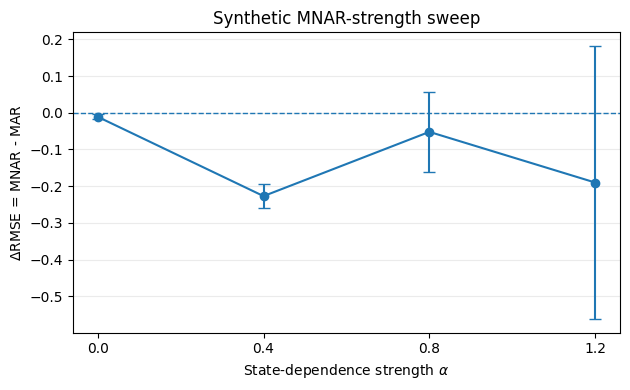

Saved: final_reviewer_outputs\figures\synthetic_validation_alpha_sweep_clean.png


,alpha,mar_mean,mar_std,mnar_mean,mnar_std,delta_mean,delta_std
0,0.0,3.741,0.026,3.730,0.023,-0.011,0.007
1,0.4,3.858,0.082,3.630,0.063,-0.227,0.033
2,0.8,3.750,0.445,3.698,0.538,-0.052,0.109
3,1.2,3.849,0.510,3.659,0.946,-0.190,0.372


In [14]:
# ============================================================
# 9) Clean synthetic alpha-sweep plot
# ============================================================

alpha_df = pd.DataFrame({
    "alpha": [0.0, 0.4, 0.8, 1.2],
    "mar_mean": [3.741, 3.858, 3.750, 3.849],
    "mar_std": [0.026, 0.082, 0.445, 0.510],
    "mnar_mean": [3.730, 3.630, 3.698, 3.659],
    "mnar_std": [0.023, 0.063, 0.538, 0.946],
    "delta_mean": [-0.011, -0.227, -0.052, -0.190],
    "delta_std": [0.007, 0.033, 0.109, 0.372],
})

alpha_df.to_csv(TABLE_DIR / "synthetic_alpha_sweep_delta_clean.csv", index=False)

plt.figure(figsize=(6.4, 4.0))
plt.axhline(0, linestyle="--", linewidth=1)
plt.errorbar(
    alpha_df["alpha"],
    alpha_df["delta_mean"],
    yerr=alpha_df["delta_std"],
    marker="o",
    capsize=4,
)
plt.xlabel(r"State-dependence strength $\alpha$")
plt.ylabel(r"$\Delta$RMSE = MNAR - MAR")
plt.title("Synthetic MNAR-strength sweep")
plt.xticks(alpha_df["alpha"])
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

out_path = FIG_DIR / "synthetic_validation_alpha_sweep_clean.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
display(alpha_df.round(3))

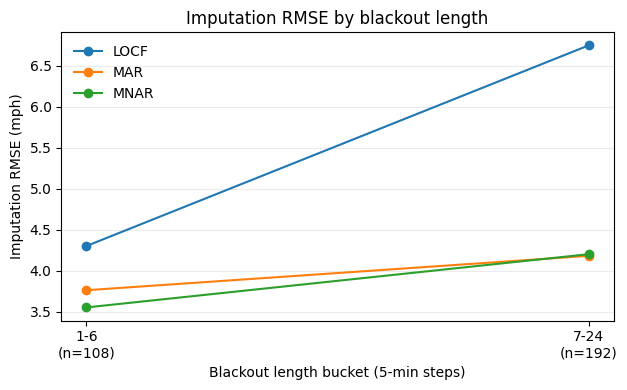

Saved: final_reviewer_outputs\figures\impute_rmse_by_length_bucket_counts.png
Saved: final_reviewer_outputs\tables\seattle_impute_rmse_by_length_bucket_clean.csv


,method,length_bucket,rmse,n_windows
0,LOCF,1-6,4.30,108
1,MAR,1-6,3.76,108
2,MNAR,1-6,3.55,108
3,LOCF,7-24,6.75,192
4,MAR,7-24,4.18,192
5,MNAR,7-24,4.20,192


In [17]:
# ============================================================
# Clean Fig. 3: imputation RMSE by blackout length bucket
# Drops empty buckets completely
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT = Path("final_reviewer_outputs")
FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Use existing generated table if available.
table_path = TABLE_DIR / "seattle_impute_rmse_by_length_bucket.csv"

if table_path.exists():
    bylen = pd.read_csv(table_path)

    # Normalize likely column names
    if "length_bucket" not in bylen.columns:
        for c in bylen.columns:
            if "bucket" in c.lower():
                bylen = bylen.rename(columns={c: "length_bucket"})
                break

    if "n_windows" not in bylen.columns:
        bylen["n_windows"] = np.nan

    # Drop empty buckets
    bylen = bylen[
        bylen["length_bucket"].notna()
        & bylen["rmse"].notna()
        & ((bylen["n_windows"].isna()) | (bylen["n_windows"] > 0))
    ].copy()

else:
    # Fallback from the current figure/table values.
    # Use only as a plotting fallback if no per-window bucket table exists.
    bylen = pd.DataFrame([
        {"method": "LOCF", "length_bucket": "1-6", "rmse": 4.30, "n_windows": 108},
        {"method": "MAR",  "length_bucket": "1-6", "rmse": 3.76, "n_windows": 108},
        {"method": "MNAR", "length_bucket": "1-6", "rmse": 3.55, "n_windows": 108},

        {"method": "LOCF", "length_bucket": "7-24", "rmse": 6.75, "n_windows": 192},
        {"method": "MAR",  "length_bucket": "7-24", "rmse": 4.18, "n_windows": 192},
        {"method": "MNAR", "length_bucket": "7-24", "rmse": 4.20, "n_windows": 192},
    ])

# Clean method labels
bylen["method"] = bylen["method"].replace({
    "MAR (LDS)": "MAR",
    "MNAR (LDS)": "MNAR",
})

bucket_order = ["1-6", "7-12", "13-24", "7-24", "25-72", "73+"]
present_buckets = [
    b for b in bucket_order
    if b in set(bylen["length_bucket"].astype(str))
]

# Drop buckets with zero counts if any survived
counts = (
    bylen.groupby("length_bucket", as_index=False)["n_windows"]
    .max()
)
counts = counts[counts["n_windows"].fillna(1) > 0]
present_buckets = [
    b for b in present_buckets
    if b in set(counts["length_bucket"].astype(str))
]

method_order = ["LOCF", "MAR", "MNAR"]

plt.figure(figsize=(6.4, 4.0))

x = np.arange(len(present_buckets))

for method in method_order:
    gm = bylen[bylen["method"] == method].copy()
    if gm.empty:
        continue

    gm["length_bucket"] = gm["length_bucket"].astype(str)
    gm = gm.set_index("length_bucket").reindex(present_buckets)

    plt.plot(
        x,
        gm["rmse"].to_numpy(dtype=float),
        marker="o",
        label=method,
    )

count_map = counts.set_index("length_bucket")["n_windows"].to_dict()
xtick_labels = [
    f"{b}\n(n={int(count_map[b])})" if b in count_map and pd.notna(count_map[b]) else b
    for b in present_buckets
]

plt.xticks(x, xtick_labels)
plt.xlabel("Blackout length bucket (5-min steps)")
plt.ylabel("Imputation RMSE (mph)")
plt.title("Imputation RMSE by blackout length")
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

out_path = FIG_DIR / "impute_rmse_by_length_bucket_counts.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

bylen_clean_path = TABLE_DIR / "seattle_impute_rmse_by_length_bucket_clean.csv"
bylen.to_csv(bylen_clean_path, index=False)

print("Saved:", out_path)
print("Saved:", bylen_clean_path)
display(bylen)

In [19]:
# ============================================================
# 15) Neural missing-data baselines: setup and eval-window parser
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
except Exception as e:
    raise ImportError(
        "PyTorch is required. Install with: python -m pip install torch"
    ) from e

DATA_DIR = Path("data")
OUT = Path("final_reviewer_outputs")
FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

# Keep these small first. Increase epochs only if results look stable.
SEQ_LEN = 96          # 8 hours at 5-min resolution
BATCH_SIZE = 16
TRAIN_STEPS = 1200   # first sanity run; increase to 3000+ if needed
LR = 1e-3
HIDDEN = 64
RANDOM_MASK_PROB = 0.15
SEED = 123

np.random.seed(SEED)
torch.manual_seed(SEED)

X_raw = np.load(DATA_DIR / "x_t_nan.npy").astype(np.float32)
detector_ids = np.load(DATA_DIR / "detector_ids.npy", allow_pickle=True).astype(str)
eval_windows = pd.read_parquet(DATA_DIR / "evaluation_windows.parquet")

T, D = X_raw.shape
print("X_raw:", X_raw.shape)
print("evaluation_windows:", eval_windows.shape)
print("columns:", list(eval_windows.columns))

# Normalize by detector using observed values only
mu = np.nanmean(X_raw, axis=0).astype(np.float32)
sigma = np.nanstd(X_raw, axis=0).astype(np.float32)
sigma[sigma < 1e-6] = 1.0

X = (X_raw - mu[None, :]) / sigma[None, :]
obs_mask = np.isfinite(X).astype(np.float32)
X_filled = np.where(np.isfinite(X), X, 0.0).astype(np.float32)

def first_col(df, candidates):
    lower_to_col = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower_to_col:
            return lower_to_col[c.lower()]
    for c in df.columns:
        cl = c.lower()
        for cand in candidates:
            if cand.lower() in cl:
                return c
    return None

def clean_task_horizon(task=None, horizon=None, source=""):
    text = " ".join([
        str(task) if task is not None else "",
        str(horizon) if horizon is not None else "",
        str(source),
    ]).lower()

    if "imput" in text or "recon" in text:
        return "impute"

    for h in [1, 3, 6]:
        pats = [
            f"{h}-step", f"{h} step", f"h{h}", f"h={h}",
            f"horizon_{h}", f"horizon {h}", f"{h}step"
        ]
        if any(p in text for p in pats):
            return f"{h}-step"

    try:
        hv = int(float(str(horizon)))
        if hv in [1, 3, 6]:
            return f"{hv}-step"
    except Exception:
        pass

    return "unknown"

def infer_detector_index(row, detector_col):
    val = row[detector_col]

    try:
        iv = int(val)
        if 0 <= iv < len(detector_ids):
            return iv
    except Exception:
        pass

    sval = str(val)
    hits = np.where(detector_ids == sval)[0]
    if len(hits) > 0:
        return int(hits[0])

    return None

def infer_time_index_from_timestamp(ts):
    ts = pd.to_datetime(ts)
    base = pd.Timestamp("2015-01-01 00:00:00")
    return int(round((ts - base).total_seconds() / (5 * 60)))

def value_to_index(v):
    if pd.isna(v):
        return None

    if isinstance(v, (int, np.integer)):
        return int(v)

    if isinstance(v, (float, np.floating)) and np.isfinite(v):
        return int(v)

    try:
        return int(float(v))
    except Exception:
        return infer_time_index_from_timestamp(v)

detector_col = first_col(eval_windows, [
    "detector_idx", "det_idx", "sensor_idx",
    "detector_id", "detector", "det", "sensor"
])
start_col = first_col(eval_windows, [
    "start_idx", "blackout_start_idx", "s_idx", "s",
    "start_index", "start_time", "blackout_start", "start"
])
end_col = first_col(eval_windows, [
    "end_idx", "blackout_end_idx", "e_idx", "e",
    "end_index", "end_time", "blackout_end", "end"
])
len_col = first_col(eval_windows, [
    "blackout_len", "length", "len", "duration", "blackout_length"
])
task_col = first_col(eval_windows, ["task", "type", "eval_task"])
horizon_col = first_col(eval_windows, ["horizon", "h", "step", "forecast_horizon"])
window_col = first_col(eval_windows, ["window_id", "window", "id", "event_id"])

print("Detected:")
print("detector_col:", detector_col)
print("start_col:", start_col)
print("end_col:", end_col)
print("len_col:", len_col)
print("task_col:", task_col)
print("horizon_col:", horizon_col)
print("window_col:", window_col)

if detector_col is None or start_col is None:
    raise RuntimeError("Could not infer detector/start columns from evaluation_windows.parquet.")

# Build imputation windows only. GRU-D/BRITS/Diffusion imputers are naturally imputation baselines.
eval_rows = []

for i, row in eval_windows.iterrows():
    task_val = row[task_col] if task_col is not None else None
    horizon_val = row[horizon_col] if horizon_col is not None else None
    task_horizon = clean_task_horizon(task_val, horizon_val, source="evaluation_windows")

    if task_horizon != "impute":
        continue

    det_idx = infer_detector_index(row, detector_col)
    if det_idx is None:
        continue

    start_idx = value_to_index(row[start_col])
    if start_idx is None:
        continue

    end_idx = None
    if end_col is not None:
        end_idx = value_to_index(row[end_col])

    if end_idx is None and len_col is not None and not pd.isna(row[len_col]):
        end_idx = start_idx + int(float(row[len_col]))

    if end_idx is None:
        continue

    # Treat end as exclusive. If it is inclusive, this only affects 1 point and will be obvious.
    target_idxs = np.arange(start_idx, end_idx, dtype=int)
    target_idxs = target_idxs[(target_idxs >= 0) & (target_idxs < T)]

    # Keep only targets with true observed values.
    target_idxs = np.array([t for t in target_idxs if np.isfinite(X_raw[t, det_idx])], dtype=int)

    if len(target_idxs) == 0:
        continue

    eval_rows.append({
        "row_id": i,
        "window_id": str(row[window_col]) if window_col is not None else f"row_{i}",
        "det_idx": int(det_idx),
        "start_idx": int(start_idx),
        "end_idx": int(end_idx),
        "target_idxs": target_idxs,
        "blackout_len": int(len(target_idxs)),
    })

print("Usable imputation windows:", len(eval_rows))
print("Total target points:", sum(len(r["target_idxs"]) for r in eval_rows))

if len(eval_rows) == 0:
    raise RuntimeError("No usable imputation windows found.")

Using device: cpu
X_raw: (105120, 147)
evaluation_windows: (1764, 7)
columns: ['window_id', 'detector_id', 'blackout_start', 'blackout_end', 'len_steps', 'test_type', 'horizon_steps']
Detected:
detector_col: detector_id
start_col: blackout_start
end_col: blackout_end
len_col: len_steps
task_col: test_type
horizon_col: len_steps
window_col: window_id
Usable imputation windows: 441
Total target points: 5673


In [28]:
# ============================================================
# 15b) Leakage-free training panel for neural baselines
# ============================================================

X_filled_leakage_free = X_filled.copy()
obs_mask_leakage_free = obs_mask.copy()

masked_count = 0

for r in eval_rows:
    det_idx = r["det_idx"]
    target_idxs = r["target_idxs"]

    for t in target_idxs:
        if 0 <= t < X_filled_leakage_free.shape[0]:
            X_filled_leakage_free[t, det_idx] = 0.0
            obs_mask_leakage_free[t, det_idx] = 0.0
            masked_count += 1

# Replace globals used by Cell 16 training dataset and Cell 19 evaluation input.
# X_raw is still preserved separately for ground truth.
X_filled = X_filled_leakage_free
obs_mask = obs_mask_leakage_free

print("Masked evaluation target entries from neural training/input panel:", masked_count)
print("Training observed fraction after masking:", obs_mask.mean())

Masked evaluation target entries from neural training/input panel: 5673
Training observed fraction after masking: 0.947865


In [29]:
# ============================================================
# 16) Self-supervised training data for imputation baselines
# ============================================================

class RandomMaskSequenceDataset(Dataset):
    def __init__(self, X_filled, obs_mask, seq_len=96, n_samples=20000, random_mask_prob=0.15, seed=123):
        self.X_filled = X_filled
        self.obs_mask = obs_mask
        self.seq_len = seq_len
        self.n_samples = n_samples
        self.random_mask_prob = random_mask_prob
        self.rng = np.random.default_rng(seed)
        self.T, self.D = X_filled.shape

        valid_starts = np.arange(0, self.T - self.seq_len)
        self.valid_starts = valid_starts

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        s = int(self.rng.choice(self.valid_starts))
        e = s + self.seq_len

        x_true = self.X_filled[s:e].copy()
        obs = self.obs_mask[s:e].copy()

        # Artificially hide observed values as reconstruction targets
        artificial = (self.rng.random(size=obs.shape) < self.random_mask_prob).astype(np.float32)
        target_mask = obs * artificial

        input_mask = obs * (1.0 - artificial)
        x_input = x_true * input_mask

        return {
            "x_input": torch.tensor(x_input, dtype=torch.float32),
            "input_mask": torch.tensor(input_mask, dtype=torch.float32),
            "x_true": torch.tensor(x_true, dtype=torch.float32),
            "target_mask": torch.tensor(target_mask, dtype=torch.float32),
        }

train_ds = RandomMaskSequenceDataset(
    X_filled=X_filled,
    obs_mask=obs_mask,
    seq_len=SEQ_LEN,
    n_samples=TRAIN_STEPS * BATCH_SIZE,
    random_mask_prob=RANDOM_MASK_PROB,
    seed=SEED,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

print("Dataset ready.")

Dataset ready.


In [30]:
# ============================================================
# 17) Local GRU-D, BRITS-style, and diffusion-style imputers
# ============================================================

class GRUDStyleImputer(nn.Module):
    def __init__(self, D, hidden=64):
        super().__init__()
        self.D = D
        self.hidden = hidden

        self.gamma_x = nn.Parameter(torch.zeros(D))
        self.gamma_h = nn.Linear(D, hidden)
        self.gru = nn.GRUCell(2 * D, hidden)
        self.out = nn.Linear(hidden, D)

    def forward(self, x, m):
        # x, m: [B, T, D]
        B, T, D = x.shape
        h = torch.zeros(B, self.hidden, device=x.device)

        last_x = torch.zeros(B, D, device=x.device)
        preds = []

        gx = torch.sigmoid(self.gamma_x)[None, :]

        for t in range(T):
            mt = m[:, t, :]
            xt = x[:, t, :]

            last_x = mt * xt + (1.0 - mt) * last_x
            x_imp = mt * xt + (1.0 - mt) * (gx * last_x)

            gh = torch.sigmoid(self.gamma_h(1.0 - mt))
            h = gh * h

            inp = torch.cat([x_imp, mt], dim=-1)
            h = self.gru(inp, h)
            preds.append(self.out(h))

        return torch.stack(preds, dim=1)


class BRITSStyleImputer(nn.Module):
    def __init__(self, D, hidden=64):
        super().__init__()
        self.fwd = nn.GRU(input_size=2 * D, hidden_size=hidden, batch_first=True)
        self.bwd = nn.GRU(input_size=2 * D, hidden_size=hidden, batch_first=True)
        self.out_f = nn.Linear(hidden, D)
        self.out_b = nn.Linear(hidden, D)

    def forward(self, x, m):
        inp = torch.cat([x, m], dim=-1)

        hf, _ = self.fwd(inp)
        pf = self.out_f(hf)

        rev_inp = torch.flip(inp, dims=[1])
        hb, _ = self.bwd(rev_inp)
        pb = self.out_b(hb)
        pb = torch.flip(pb, dims=[1])

        pred = 0.5 * (pf + pb)
        consistency = torch.mean((pf - pb) ** 2)

        return pred, consistency


class DiffusionStyleImputer(nn.Module):
    def __init__(self, D, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2 * D + 1, hidden, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(hidden, D, kernel_size=5, padding=2),
        )

    def forward(self, x, m):
        # Simple denoising model with random noise level channel
        B, T, D = x.shape
        noise_level = torch.rand(B, 1, 1, device=x.device)
        noise = torch.randn_like(x) * noise_level
        x_noisy = x + noise * (1.0 - m)

        nl = noise_level.expand(B, T, 1)
        inp = torch.cat([x_noisy, m, nl], dim=-1)  # [B,T,2D+1]
        inp = inp.transpose(1, 2)                  # [B,2D+1,T]
        pred = self.net(inp).transpose(1, 2)       # [B,T,D]
        return pred


def masked_mse(pred, target, mask):
    denom = mask.sum().clamp_min(1.0)
    return (((pred - target) ** 2) * mask).sum() / denom


def train_model(model, name, train_loader, steps=1200, lr=1e-3):
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    t0 = time.time()

    loader_iter = iter(train_loader)

    for step in range(1, steps + 1):
        try:
            batch = next(loader_iter)
        except StopIteration:
            loader_iter = iter(train_loader)
            batch = next(loader_iter)

        x_input = batch["x_input"].to(DEVICE)
        input_mask = batch["input_mask"].to(DEVICE)
        x_true = batch["x_true"].to(DEVICE)
        target_mask = batch["target_mask"].to(DEVICE)

        opt.zero_grad()

        if name == "BRITS":
            pred, consistency = model(x_input, input_mask)
            loss = masked_mse(pred, x_true, target_mask) + 0.1 * consistency
        else:
            pred = model(x_input, input_mask)
            loss = masked_mse(pred, x_true, target_mask)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        losses.append(float(loss.detach().cpu()))

        if step % 200 == 0 or step == 1:
            print(f"{name:18s} step {step:5d}/{steps} | loss={losses[-1]:.5f}")

    print(f"{name} done in {(time.time() - t0)/60:.1f} min")
    return model, losses


print("Models defined.")

Models defined.



Training: GRU-D-style
GRU-D-style        step     1/1200 | loss=1.08680
GRU-D-style        step   200/1200 | loss=0.27491
GRU-D-style        step   400/1200 | loss=0.25009
GRU-D-style        step   600/1200 | loss=0.19532
GRU-D-style        step   800/1200 | loss=0.16601
GRU-D-style        step  1000/1200 | loss=0.24879
GRU-D-style        step  1200/1200 | loss=0.19332
GRU-D-style done in 1.5 min

Training: BRITS-style
BRITS              step     1/1200 | loss=1.13370
BRITS              step   200/1200 | loss=0.35648
BRITS              step   400/1200 | loss=0.28878
BRITS              step   600/1200 | loss=0.21478
BRITS              step   800/1200 | loss=0.18160
BRITS              step  1000/1200 | loss=0.15867
BRITS              step  1200/1200 | loss=0.20972
BRITS done in 1.0 min

Training: Diffusion-style
Diffusion-style    step     1/1200 | loss=1.21073
Diffusion-style    step   200/1200 | loss=0.23805
Diffusion-style    step   400/1200 | loss=0.18926
Diffusion-style    step   6

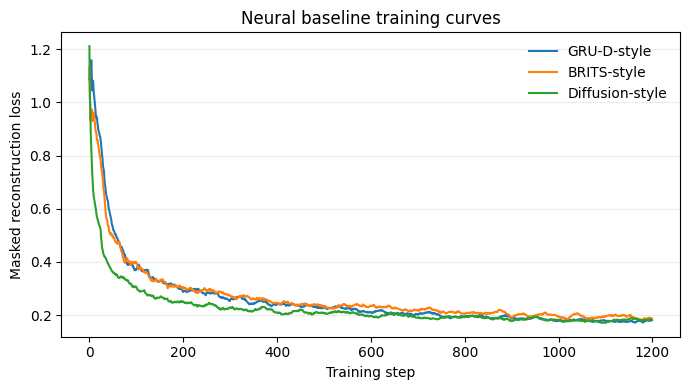

Saved: final_reviewer_outputs\figures\neural_baseline_training_curves.png


In [31]:
# ============================================================
# 18) Train neural baselines
# ============================================================

RUN_NEURAL_BASELINES = True

baseline_models = {}
baseline_losses = {}

if RUN_NEURAL_BASELINES:
    configs = [
        ("GRU-D-style", GRUDStyleImputer(D=D, hidden=HIDDEN)),
        ("BRITS-style", BRITSStyleImputer(D=D, hidden=HIDDEN)),
        ("Diffusion-style", DiffusionStyleImputer(D=D, hidden=128)),
    ]

    for name, model in configs:
        print("\n" + "=" * 70)
        print("Training:", name)
        trained, losses = train_model(
            model=model,
            name="BRITS" if name == "BRITS-style" else name,
            train_loader=train_loader,
            steps=TRAIN_STEPS,
            lr=LR,
        )

        baseline_models[name] = trained.eval()
        baseline_losses[name] = losses

        torch.save(trained.state_dict(), OUT / f"{name.replace('-', '_').replace(' ', '_')}.pt")

    loss_df = pd.DataFrame({
        name: pd.Series(losses)
        for name, losses in baseline_losses.items()
    })
    loss_df.to_csv(TABLE_DIR / "neural_baseline_training_losses.csv", index=False)

    plt.figure(figsize=(7.0, 4.0))
    for name, losses in baseline_losses.items():
        smooth = pd.Series(losses).rolling(25, min_periods=1).mean()
        plt.plot(smooth, label=name)

    plt.xlabel("Training step")
    plt.ylabel("Masked reconstruction loss")
    plt.title("Neural baseline training curves")
    plt.legend(frameon=False)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()

    out_path = FIG_DIR / "neural_baseline_training_curves.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_path)

else:
    print("Skipping training.")

In [32]:
# ============================================================
# 19) Evaluate neural baselines on blackout imputation windows
# ============================================================

@torch.no_grad()
def predict_window(model, model_name, start_idx, end_idx, det_idx):
    """
    Build a sequence ending after the blackout interval, mask the target detector
    inside the blackout, and predict the hidden values.
    """
    seq_start = max(0, end_idx - SEQ_LEN)
    seq_end = seq_start + SEQ_LEN

    if seq_end > T:
        seq_end = T
        seq_start = max(0, seq_end - SEQ_LEN)

    local_start = start_idx - seq_start
    local_end = end_idx - seq_start

    if local_start < 0 or local_end > SEQ_LEN:
        return None, None

    x_seq = X_filled[seq_start:seq_end].copy()
    m_seq = obs_mask[seq_start:seq_end].copy()

    # Artificially mask target detector during blackout
    m_seq[local_start:local_end, det_idx] = 0.0
    x_seq[local_start:local_end, det_idx] = 0.0

    xb = torch.tensor(x_seq[None, :, :], dtype=torch.float32, device=DEVICE)
    mb = torch.tensor(m_seq[None, :, :], dtype=torch.float32, device=DEVICE)

    if model_name == "BRITS-style":
        pred_scaled, _ = model(xb, mb)
    else:
        pred_scaled = model(xb, mb)

    pred_scaled = pred_scaled.detach().cpu().numpy()[0]

    return pred_scaled, seq_start


neural_pred_rows = []

for model_name, model in baseline_models.items():
    print("Evaluating:", model_name)

    for r in eval_rows:
        det_idx = r["det_idx"]
        start_idx = r["start_idx"]
        end_idx = r["end_idx"]
        target_idxs = r["target_idxs"]

        pred_scaled, seq_start = predict_window(
            model=model,
            model_name=model_name,
            start_idx=start_idx,
            end_idx=end_idx,
            det_idx=det_idx,
        )

        if pred_scaled is None:
            continue

        y_true = []
        y_pred = []

        for t in target_idxs:
            local_t = t - seq_start
            if local_t < 0 or local_t >= pred_scaled.shape[0]:
                continue

            yt = X_raw[t, det_idx]
            yp_scaled = pred_scaled[local_t, det_idx]
            yp = yp_scaled * sigma[det_idx] + mu[det_idx]

            if np.isfinite(yt) and np.isfinite(yp):
                y_true.append(float(yt))
                y_pred.append(float(yp))

        if len(y_true) == 0:
            continue

        y_true = np.asarray(y_true, dtype=np.float32)
        y_pred = np.asarray(y_pred, dtype=np.float32)

        neural_pred_rows.append({
            "dataset": "Seattle",
            "method": model_name,
            "task_horizon": "impute",
            "window_id": r["window_id"],
            "blackout_len": r["blackout_len"],
            "sqerr_sum": float(np.sum((y_pred - y_true) ** 2)),
            "n_obs": int(len(y_true)),
        })

neural_preds = pd.DataFrame(neural_pred_rows)
neural_preds.to_csv(TABLE_DIR / "neural_baseline_imputation_predictions.csv", index=False)

neural_summary = (
    neural_preds
    .groupby(["dataset", "method", "task_horizon"], as_index=False)
    .apply(lambda g: pd.Series({
        "rmse": np.sqrt(g["sqerr_sum"].sum() / g["n_obs"].sum()),
        "n_windows": g["window_id"].nunique(),
        "n_obs": int(g["n_obs"].sum()),
    }))
    .reset_index(drop=True)
)

neural_summary.to_csv(TABLE_DIR / "neural_baseline_imputation_summary.csv", index=False)

print("Saved:", TABLE_DIR / "neural_baseline_imputation_predictions.csv")
print("Saved:", TABLE_DIR / "neural_baseline_imputation_summary.csv")
display(neural_summary.round(3))

Evaluating: GRU-D-style
Evaluating: BRITS-style
Evaluating: Diffusion-style
Saved: final_reviewer_outputs\tables\neural_baseline_imputation_predictions.csv
Saved: final_reviewer_outputs\tables\neural_baseline_imputation_summary.csv


,dataset,method,task_horizon,rmse,n_windows,n_obs
0,Seattle,BRITS-style,impute,4.431,441.0,5673.0
1,Seattle,Diffusion-style,impute,4.768,441.0,5673.0
2,Seattle,GRU-D-style,impute,4.536,441.0,5673.0


,method,rmse,source
0,LOCF,7.021,paper
1,LinearInterp + SeasonalNaive,5.024,paper
6,GRU-D-style,4.536,local neural baseline
4,BRITS-style,4.431,local neural baseline
5,Diffusion-style,4.768,local neural baseline
2,MAR (LDS),4.229,paper
3,MNAR (LDS),4.195,paper


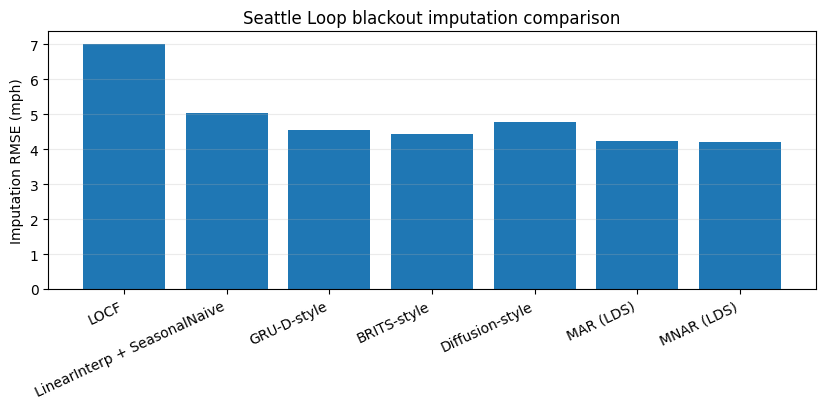

Saved: final_reviewer_outputs\tables\seattle_imputation_neural_baseline_comparison.csv
Saved: final_reviewer_outputs\figures\seattle_imputation_neural_baseline_comparison.png


In [33]:
# ============================================================
# 20) Compare LDS/MNAR against neural baselines
# ============================================================

paper_impute = pd.DataFrame([
    {"dataset": "Seattle", "method": "LOCF", "task_horizon": "impute", "rmse": 7.021, "source": "paper"},
    {"dataset": "Seattle", "method": "LinearInterp + SeasonalNaive", "task_horizon": "impute", "rmse": 5.024, "source": "paper"},
    {"dataset": "Seattle", "method": "MAR (LDS)", "task_horizon": "impute", "rmse": 4.229, "source": "paper"},
    {"dataset": "Seattle", "method": "MNAR (LDS)", "task_horizon": "impute", "rmse": 4.195, "source": "paper"},
])

neural_summary = pd.read_csv(TABLE_DIR / "neural_baseline_imputation_summary.csv")
neural_for_plot = neural_summary[["dataset", "method", "task_horizon", "rmse"]].copy()
neural_for_plot["source"] = "local neural baseline"

comparison = pd.concat([paper_impute, neural_for_plot], ignore_index=True)

method_order = [
    "LOCF",
    "LinearInterp + SeasonalNaive",
    "GRU-D-style",
    "BRITS-style",
    "Diffusion-style",
    "MAR (LDS)",
    "MNAR (LDS)",
]

comparison["method_order"] = comparison["method"].map({
    m: i for i, m in enumerate(method_order)
}).fillna(999)

comparison = comparison.sort_values(["method_order", "method"])

comparison.to_csv(TABLE_DIR / "seattle_imputation_neural_baseline_comparison.csv", index=False)

display(comparison[["method", "rmse", "source"]].round(3))

plt.figure(figsize=(8.4, 4.2))

x = np.arange(len(comparison))
plt.bar(x, comparison["rmse"].to_numpy(dtype=float))

plt.xticks(x, comparison["method"], rotation=25, ha="right")
plt.ylabel("Imputation RMSE (mph)")
plt.title("Seattle Loop blackout imputation comparison")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

out_path = FIG_DIR / "seattle_imputation_neural_baseline_comparison.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", TABLE_DIR / "seattle_imputation_neural_baseline_comparison.csv")
print("Saved:", out_path)

In [26]:
# ============================================================
# 12) Historical-profile baseline on evaluation windows
# Robust column parsing version
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")
OUT = Path("final_reviewer_outputs")
FIG_DIR = OUT / "figures"
TABLE_DIR = OUT / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


def exact_col(df, candidates):
    lower_to_col = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        if cand.lower() in lower_to_col:
            return lower_to_col[cand.lower()]
    return None


def contains_col(df, candidates, exclude=None):
    exclude = set(exclude or [])
    for cand in candidates:
        if len(cand) <= 2:
            continue
        for c in df.columns:
            if c in exclude:
                continue
            if cand.lower() in c.lower():
                return c
    return None


def choose_col(df, exact_candidates, contains_candidates=None, exclude=None):
    c = exact_col(df, exact_candidates)
    if c is not None and c not in set(exclude or []):
        return c
    return contains_col(df, contains_candidates or exact_candidates, exclude=exclude)


def safe_time_index(v):
    if pd.isna(v):
        return None

    if isinstance(v, (int, np.integer)):
        return int(v)

    if isinstance(v, (float, np.floating)) and np.isfinite(v):
        return int(v)

    s = str(v).strip()

    try:
        return int(float(s))
    except Exception:
        pass

    try:
        ts = pd.to_datetime(s)
        base = pd.Timestamp("2015-01-01 00:00:00")
        return int(round((ts - base).total_seconds() / (5 * 60)))
    except Exception:
        return None


def infer_detector_index(row, detector_col, detector_ids):
    val = row[detector_col]

    if pd.isna(val):
        return None

    try:
        iv = int(val)
        if 0 <= iv < len(detector_ids):
            return iv
    except Exception:
        pass

    sval = str(val)
    matches = np.where(detector_ids.astype(str) == sval)[0]
    if len(matches) > 0:
        return int(matches[0])

    return None


def get_window_indices(row, start_col, end_col, len_col):
    start_idx = safe_time_index(row[start_col]) if start_col is not None else None

    if start_idx is None:
        return None, None

    end_idx = None

    if end_col is not None:
        end_idx = safe_time_index(row[end_col])

    if end_idx is None and len_col is not None and not pd.isna(row[len_col]):
        try:
            length = int(float(row[len_col]))
            end_idx = start_idx + length
        except Exception:
            end_idx = None

    return start_idx, end_idx


def historical_profile_predict(X, det_idx, target_idx, cutoff_idx):
    T = X.shape[0]
    target_idx = int(target_idx)
    cutoff_idx = int(cutoff_idx)

    if target_idx < 0 or target_idx >= T:
        return np.nan

    base = pd.Timestamp("2015-01-01 00:00:00")
    all_times = pd.date_range(base, periods=T, freq="5min")
    target_time = base + pd.Timedelta(minutes=5 * target_idx)

    same_profile = (
        (all_times.dayofweek == target_time.dayofweek)
        & (all_times.hour == target_time.hour)
        & (all_times.minute == target_time.minute)
    )

    past_mask = np.arange(T) < cutoff_idx

    vals = X[same_profile & past_mask, det_idx]
    vals = vals[np.isfinite(vals)]
    if len(vals) >= 2:
        return float(np.median(vals))

    vals = X[:cutoff_idx, det_idx]
    vals = vals[np.isfinite(vals)]
    if len(vals) > 0:
        return float(np.median(vals))

    vals = X[:cutoff_idx, :]
    vals = vals[np.isfinite(vals)]
    if len(vals) > 0:
        return float(np.median(vals))

    return np.nan


def local_clean_task_horizon(row, task_col, horizon_col):
    task_text = str(row[task_col]).lower() if task_col is not None and not pd.isna(row[task_col]) else ""
    horizon_text = str(row[horizon_col]).lower() if horizon_col is not None and not pd.isna(row[horizon_col]) else ""
    text = task_text + " " + horizon_text

    if "imput" in text or "recon" in text:
        return "impute"

    for h in [1, 3, 6]:
        if (
            f"{h}-step" in text
            or f"{h} step" in text
            or f"h={h}" in text
            or f"h{h}" in text
            or f"horizon_{h}" in text
            or f"horizon {h}" in text
        ):
            return f"{h}-step"

    if horizon_col is not None and not pd.isna(row[horizon_col]):
        try:
            h = int(float(row[horizon_col]))
            if h in [1, 3, 6]:
                return f"{h}-step"
        except Exception:
            pass

    # If no task column exists, assume rows are imputation windows.
    if task_col is None and horizon_col is None:
        return "impute"

    return "unknown"


if not (DATA_DIR / "x_t_nan.npy").exists() or not (DATA_DIR / "evaluation_windows.parquet").exists():
    print("Need data/x_t_nan.npy and data/evaluation_windows.parquet for this baseline.")
else:
    X = np.load(DATA_DIR / "x_t_nan.npy")
    detector_ids = np.load(DATA_DIR / "detector_ids.npy", allow_pickle=True).astype(str)
    ew = pd.read_parquet(DATA_DIR / "evaluation_windows.parquet").copy()

    print("evaluation_windows columns:")
    print(list(ew.columns))

    detector_col = choose_col(
        ew,
        exact_candidates=[
            "detector_idx", "det_idx", "sensor_idx",
            "detector_id", "detector", "det", "sensor", "sensor_id"
        ],
        contains_candidates=["detector", "sensor"],
    )

    start_col = choose_col(
        ew,
        exact_candidates=[
            "start_idx", "blackout_start_idx", "s_idx",
            "start_index", "blackout_start_index",
            "start_time_idx", "blackout_start_time_idx",
            "start_time", "blackout_start", "start"
        ],
        contains_candidates=["start_idx", "start_index", "start_time", "blackout_start"],
        exclude=[detector_col],
    )

    end_col = choose_col(
        ew,
        exact_candidates=[
            "end_idx", "blackout_end_idx", "e_idx",
            "end_index", "blackout_end_index",
            "end_time_idx", "blackout_end_time_idx",
            "end_time", "blackout_end", "end"
        ],
        contains_candidates=["end_idx", "end_index", "end_time", "blackout_end"],
        exclude=[detector_col, start_col],
    )

    len_col = choose_col(
        ew,
        exact_candidates=[
            "blackout_len", "length", "len", "duration",
            "blackout_length", "window_len", "window_length"
        ],
        contains_candidates=["blackout_len", "blackout_length", "duration", "length"],
        exclude=[detector_col, start_col, end_col],
    )

    task_col = choose_col(
        ew,
        exact_candidates=["task", "type", "eval_task", "task_horizon"],
        contains_candidates=["task", "type"],
        exclude=[detector_col, start_col, end_col, len_col],
    )

    horizon_col = choose_col(
        ew,
        exact_candidates=["horizon", "h", "step", "forecast_horizon"],
        contains_candidates=["horizon", "forecast"],
        exclude=[detector_col, start_col, end_col, len_col, task_col],
    )

    target_col = choose_col(
        ew,
        exact_candidates=["target_idx", "forecast_idx", "y_idx", "target_index"],
        contains_candidates=["target_idx", "forecast_idx", "target_index"],
        exclude=[detector_col, start_col, end_col, len_col, task_col, horizon_col],
    )

    window_col = choose_col(
        ew,
        exact_candidates=["window_id", "window", "id", "event_id"],
        contains_candidates=["window_id", "event_id"],
        exclude=[detector_col, start_col, end_col, len_col, task_col, horizon_col, target_col],
    )

    print("\nDetected columns:")
    print("detector_col:", detector_col)
    print("start_col:   ", start_col)
    print("end_col:     ", end_col)
    print("len_col:     ", len_col)
    print("task_col:    ", task_col)
    print("horizon_col: ", horizon_col)
    print("target_col:  ", target_col)
    print("window_col:  ", window_col)

    if detector_col is None or start_col is None:
        raise RuntimeError("Could not find required detector/start columns.")

    pred_rows = []
    skipped_bad_end = 0
    skipped_unknown_task = 0

    for i, row in ew.iterrows():
        det_idx = infer_detector_index(row, detector_col, detector_ids)
        if det_idx is None:
            continue

        start_idx, end_idx = get_window_indices(row, start_col, end_col, len_col)
        if start_idx is None:
            continue

        task_horizon = local_clean_task_horizon(row, task_col, horizon_col)

        window_id = str(row[window_col]) if window_col is not None else f"row_{i}"

        if task_horizon == "impute":
            if end_idx is None:
                skipped_bad_end += 1
                continue

            idxs = np.arange(start_idx, end_idx, dtype=int)
            if len(idxs) == 0:
                idxs = np.array([start_idx], dtype=int)

        elif task_horizon in ["1-step", "3-step", "6-step"]:
            if target_col is not None and not pd.isna(row[target_col]):
                target_idx = safe_time_index(row[target_col])
            else:
                h = int(task_horizon.split("-")[0])
                if end_idx is None:
                    skipped_bad_end += 1
                    continue
                target_idx = end_idx + h - 1

            if target_idx is None:
                continue

            idxs = np.array([target_idx], dtype=int)

        else:
            skipped_unknown_task += 1
            continue

        y_true = []
        y_pred = []

        for target_idx in idxs:
            if target_idx < 0 or target_idx >= X.shape[0]:
                continue

            yt = X[target_idx, det_idx]
            if not np.isfinite(yt):
                continue

            yp = historical_profile_predict(X, det_idx, target_idx, cutoff_idx=start_idx)
            if not np.isfinite(yp):
                continue

            y_true.append(float(yt))
            y_pred.append(float(yp))

        if len(y_true) == 0:
            continue

        y_true = np.asarray(y_true, dtype=float)
        y_pred = np.asarray(y_pred, dtype=float)

        pred_rows.append({
            "dataset": "Seattle",
            "method": "HistoricalProfile",
            "task_horizon": task_horizon,
            "window_id": window_id,
            "blackout_len": float(len(idxs)),
            "sqerr_sum": float(np.sum((y_pred - y_true) ** 2)),
            "n_obs": int(len(y_true)),
        })

    hist_pred = pd.DataFrame(pred_rows)

    print("\nRows produced:", len(hist_pred))
    print("Skipped bad end:", skipped_bad_end)
    print("Skipped unknown task:", skipped_unknown_task)

    if hist_pred.empty:
        print("HistoricalProfile baseline could not be computed from current evaluation_windows columns.")
    else:
        hist_pred.to_csv(TABLE_DIR / "historical_profile_predictions.csv", index=False)

        hist_summary = (
            hist_pred
            .groupby(["dataset", "method", "task_horizon"], as_index=False)
            .apply(lambda g: pd.Series({
                "rmse": np.sqrt(g["sqerr_sum"].sum() / g["n_obs"].sum()),
                "n_windows": g["window_id"].nunique(),
                "n_obs": int(g["n_obs"].sum()),
            }))
            .reset_index(drop=True)
        )

        hist_summary["horizon_order"] = hist_summary["task_horizon"].map(
            {h: i for i, h in enumerate(HORIZON_ORDER)}
        ).fillna(999)

        hist_summary = hist_summary.sort_values(["dataset", "horizon_order"])
        hist_summary.to_csv(TABLE_DIR / "historical_profile_summary.csv", index=False)

        print("Saved:", TABLE_DIR / "historical_profile_predictions.csv")
        print("Saved:", TABLE_DIR / "historical_profile_summary.csv")
        display(hist_summary.round(3))

evaluation_windows columns:
['window_id', 'detector_id', 'blackout_start', 'blackout_end', 'len_steps', 'test_type', 'horizon_steps']

Detected columns:
detector_col: detector_id
start_col:    blackout_start
end_col:      blackout_end
len_col:      None
task_col:     test_type
horizon_col:  horizon_steps
target_col:   None
window_col:   window_id

Rows produced: 1764
Skipped bad end: 0
Skipped unknown task: 0
Saved: final_reviewer_outputs\tables\historical_profile_predictions.csv
Saved: final_reviewer_outputs\tables\historical_profile_summary.csv


,dataset,method,task_horizon,rmse,n_windows,n_obs,horizon_order
3,Seattle,HistoricalProfile,impute,7.359,441.0,5673.0,0
0,Seattle,HistoricalProfile,1-step,6.597,441.0,441.0,1
1,Seattle,HistoricalProfile,3-step,6.996,441.0,441.0,2
2,Seattle,HistoricalProfile,6-step,7.153,441.0,441.0,3


task_horizon,impute,1-step,3-step,6-step
method,,,,
LOCF,7.021,7.860,8.465,8.942
LinearInterp + SeasonalNaive,5.024,8.734,8.442,8.881
MAR (LDS),4.229,4.391,4.349,5.160
MNAR (LDS),4.195,4.313,4.228,5.104
HistoricalProfile,7.359,6.597,6.996,7.153


Saved: final_reviewer_outputs\tables\main_rmse_with_historical_profile.csv


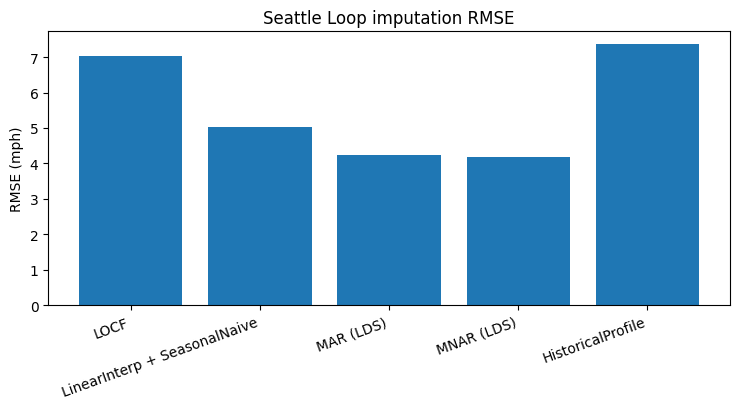

Saved: final_reviewer_outputs\figures\seattle_impute_with_historical_profile.png


In [27]:
# ============================================================
# 13) Add HistoricalProfile to Seattle comparison if available
# ============================================================

hist_summary_path = TABLE_DIR / "historical_profile_summary.csv"

if hist_summary_path.exists():
    hist_summary = pd.read_csv(hist_summary_path)

    main_base = main.drop(columns=[c for c in ["method_order", "horizon_order"] if c in main.columns]).copy()

    hist_for_main = hist_summary[["dataset", "method", "task_horizon", "rmse", "n_windows", "n_obs"]].copy()
    hist_for_main["aggregate_only"] = False

    main_plus_hist = pd.concat([main_base, hist_for_main], ignore_index=True, sort=False)

    method_order_plus = PAPER_METHOD_ORDER + ["HistoricalProfile"]
    main_plus_hist["method_order"] = main_plus_hist["method"].map(
        {m: i for i, m in enumerate(method_order_plus)}
    ).fillna(999)
    main_plus_hist["horizon_order"] = main_plus_hist["task_horizon"].map(
        {h: i for i, h in enumerate(HORIZON_ORDER)}
    ).fillna(999)

    main_plus_hist = main_plus_hist.sort_values(
        ["dataset", "horizon_order", "method_order", "method"]
    )

    out_csv = TABLE_DIR / "main_rmse_with_historical_profile.csv"
    main_plus_hist.to_csv(out_csv, index=False)

    sea = main_plus_hist[main_plus_hist["dataset"] == "Seattle"].copy()
    piv = sea.pivot_table(
        index="method",
        columns="task_horizon",
        values="rmse",
        aggfunc="first",
    )

    cols = [c for c in HORIZON_ORDER if c in piv.columns]
    idx = [m for m in method_order_plus if m in piv.index]
    piv = piv.loc[idx, cols]

    display(piv.round(3))
    print("Saved:", out_csv)

    # Clean plot
    sea_imp = sea[sea["task_horizon"] == "impute"].copy()
    sea_imp["method_order"] = sea_imp["method"].map(
        {m: i for i, m in enumerate(method_order_plus)}
    ).fillna(999)
    sea_imp = sea_imp.sort_values(["method_order", "method"])

    plt.figure(figsize=(7.5, 4.2))
    x = np.arange(len(sea_imp))
    plt.bar(x, sea_imp["rmse"].to_numpy(float))
    plt.xticks(x, sea_imp["method"], rotation=20, ha="right")
    plt.ylabel("RMSE (mph)")
    plt.title("Seattle Loop imputation RMSE")
    plt.tight_layout()

    out_fig = FIG_DIR / "seattle_impute_with_historical_profile.png"
    plt.savefig(out_fig, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", out_fig)

else:
    print("No historical_profile_summary.csv found. Run Cell 12 first.")

,method,rmse,source
0,LOCF,7.021,paper aggregate
1,LinearInterp + SeasonalNaive,5.024,paper aggregate
7,HistoricalProfile,7.359,local historical baseline
6,GRU-D-style,4.536,local neural baseline
4,BRITS-style,4.431,local neural baseline
5,Diffusion-style,4.768,local neural baseline
2,MAR (LDS),4.229,paper aggregate
3,MNAR (LDS),4.195,paper aggregate


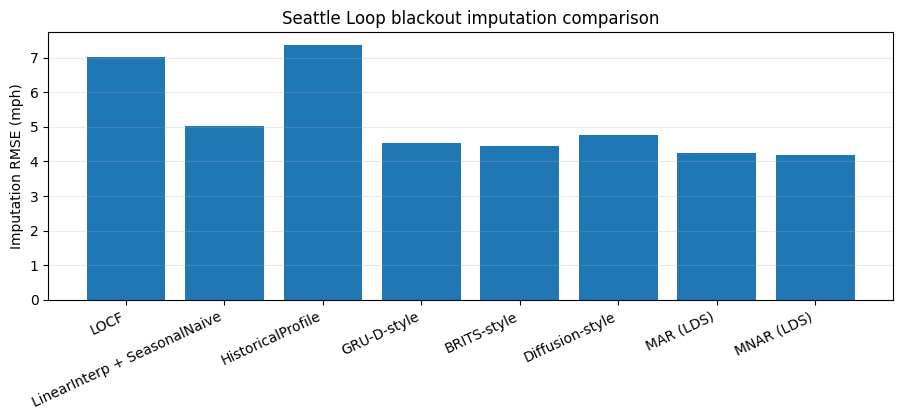

Saved: final_reviewer_outputs\tables\seattle_imputation_all_baseline_comparison.csv
Saved: final_reviewer_outputs\figures\seattle_imputation_all_baseline_comparison.png


In [34]:
# ============================================================
# Combined imputation comparison:
# heuristics + local neural baselines + HistoricalProfile + LDS
# ============================================================

paper_impute = pd.DataFrame([
    {"dataset": "Seattle", "method": "LOCF", "task_horizon": "impute", "rmse": 7.021, "source": "paper aggregate"},
    {"dataset": "Seattle", "method": "LinearInterp + SeasonalNaive", "task_horizon": "impute", "rmse": 5.024, "source": "paper aggregate"},
    {"dataset": "Seattle", "method": "MAR (LDS)", "task_horizon": "impute", "rmse": 4.229, "source": "paper aggregate"},
    {"dataset": "Seattle", "method": "MNAR (LDS)", "task_horizon": "impute", "rmse": 4.195, "source": "paper aggregate"},
])

extra_rows = []

neural_path = TABLE_DIR / "neural_baseline_imputation_summary.csv"
if neural_path.exists():
    neural_summary = pd.read_csv(neural_path)
    neural_for_plot = neural_summary[["dataset", "method", "task_horizon", "rmse"]].copy()
    neural_for_plot["source"] = "local neural baseline"
    extra_rows.append(neural_for_plot)

hist_path = TABLE_DIR / "historical_profile_summary.csv"
if hist_path.exists():
    hist_summary = pd.read_csv(hist_path)
    hist_for_plot = hist_summary[
        (hist_summary["dataset"] == "Seattle")
        & (hist_summary["task_horizon"] == "impute")
    ][["dataset", "method", "task_horizon", "rmse"]].copy()
    hist_for_plot["source"] = "local historical baseline"
    extra_rows.append(hist_for_plot)

if extra_rows:
    extra = pd.concat(extra_rows, ignore_index=True)
    comparison = pd.concat([paper_impute, extra], ignore_index=True)
else:
    comparison = paper_impute.copy()

method_order = [
    "LOCF",
    "LinearInterp + SeasonalNaive",
    "HistoricalProfile",
    "GRU-D-style",
    "BRITS-style",
    "Diffusion-style",
    "MAR (LDS)",
    "MNAR (LDS)",
]

comparison["method_order"] = comparison["method"].map({
    m: i for i, m in enumerate(method_order)
}).fillna(999)

comparison = comparison.sort_values(["method_order", "method"])

out_csv = TABLE_DIR / "seattle_imputation_all_baseline_comparison.csv"
comparison.to_csv(out_csv, index=False)

display(comparison[["method", "rmse", "source"]].round(3))

plt.figure(figsize=(9.2, 4.3))

x = np.arange(len(comparison))
plt.bar(x, comparison["rmse"].to_numpy(dtype=float))

plt.xticks(x, comparison["method"], rotation=25, ha="right")
plt.ylabel("Imputation RMSE (mph)")
plt.title("Seattle Loop blackout imputation comparison")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

out_fig = FIG_DIR / "seattle_imputation_all_baseline_comparison.png"
plt.savefig(out_fig, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_csv)
print("Saved:", out_fig)